## KHỞI TẠO ĐƯỜNG DẪN & LOAD DATA

In [1]:
# ==============================================================================
# CELL 0: NẠP TOÀN BỘ DATASET (MASTER + PRE_PROCESSED FULL)
# ==============================================================================
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

# 1. THIẾT LẬP ĐƯỜNG DẪN TƯƠNG ĐỐI TỰ ĐỘNG
ROOT_DIR = '.' if os.path.exists(os.path.join('.', 'data')) else '..'
DATA_DIR = os.path.join(ROOT_DIR, 'data', 'processed')
MASTER_DIR = os.path.join(DATA_DIR, 'master')
PRE_PROCESSED_DIR = os.path.join(DATA_DIR, 'pre_processed')

# TẠO THƯ MỤC LƯU ẢNH 
FIG_DIR = os.path.join(ROOT_DIR, 'output', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

print("Đang nạp hệ thống dữ liệu toàn diện")

data_dict = {}

# 2. DANH SÁCH CÁC FILE CẦN NẠP (Full bộ pre_processed mày đã cung cấp)
files_to_load = {
    'master': (MASTER_DIR, 'master_sales_detail.csv'),
    'orders': (PRE_PROCESSED_DIR, 'orders_preprocessed.csv'),
    'items': (PRE_PROCESSED_DIR, 'order_items_preprocessed.csv'),
    'customers': (PRE_PROCESSED_DIR, 'customers_preprocessed.csv'),
    'geography': (PRE_PROCESSED_DIR, 'geography_preprocessed.csv'),
    'products': (PRE_PROCESSED_DIR, 'products_preprocessed.csv'),
    'payments': (PRE_PROCESSED_DIR, 'payments_preprocessed.csv'),
    'shipments': (PRE_PROCESSED_DIR, 'shipments_preprocessed.csv'),
    'returns': (PRE_PROCESSED_DIR, 'returns_preprocessed.csv'),
    'reviews': (PRE_PROCESSED_DIR, 'reviews_preprocessed.csv'),
    'promotions': (PRE_PROCESSED_DIR, 'promotions_preprocessed.csv'),
    'inventory': (PRE_PROCESSED_DIR, 'inventory_preprocessed.csv'),
    'traffic': (PRE_PROCESSED_DIR, 'web_traffic_preprocessed.csv'),
    'sales_daily': (PRE_PROCESSED_DIR, 'sales_preprocessed.csv')
}

# 3. THỰC THI NẠP DATA VỚI CƠ CHẾ KIỂM SOÁT LỖI
for key, (folder, filename) in files_to_load.items():
    path = os.path.join(folder, filename)
    try:
        data_dict[key] = pd.read_csv(path)
        print(f"✅ [{key:12}] -> {data_dict[key].shape[0]:>8,} dòng.")
    except FileNotFoundError:
        print(f"❌ [{key:12}] -> KHÔNG TÌM THẤY file tại: {path}")
    except Exception as e:
        print(f"⚠️ [{key:12}] -> Lỗi khi nạp: {e}")

print("-" * 50)


Đang nạp hệ thống dữ liệu toàn diện
✅ [master      ] ->  714,669 dòng.
✅ [orders      ] ->  646,945 dòng.
✅ [items       ] ->  714,669 dòng.
✅ [customers   ] ->  121,930 dòng.
✅ [geography   ] ->   39,948 dòng.
✅ [products    ] ->    2,412 dòng.
✅ [payments    ] ->  646,945 dòng.
✅ [shipments   ] ->  566,067 dòng.
✅ [returns     ] ->   39,939 dòng.
✅ [reviews     ] ->  113,551 dòng.
✅ [promotions  ] ->       50 dòng.
✅ [inventory   ] ->   60,247 dòng.
✅ [traffic     ] ->    3,652 dòng.
✅ [sales_daily ] ->    3,833 dòng.
--------------------------------------------------


## PHẦN 1: DESCRIPTIVE (WHAT HAPPENED?)

⏳ Đang tổng hợp dữ liệu và kết xuất nhãn báo cáo...


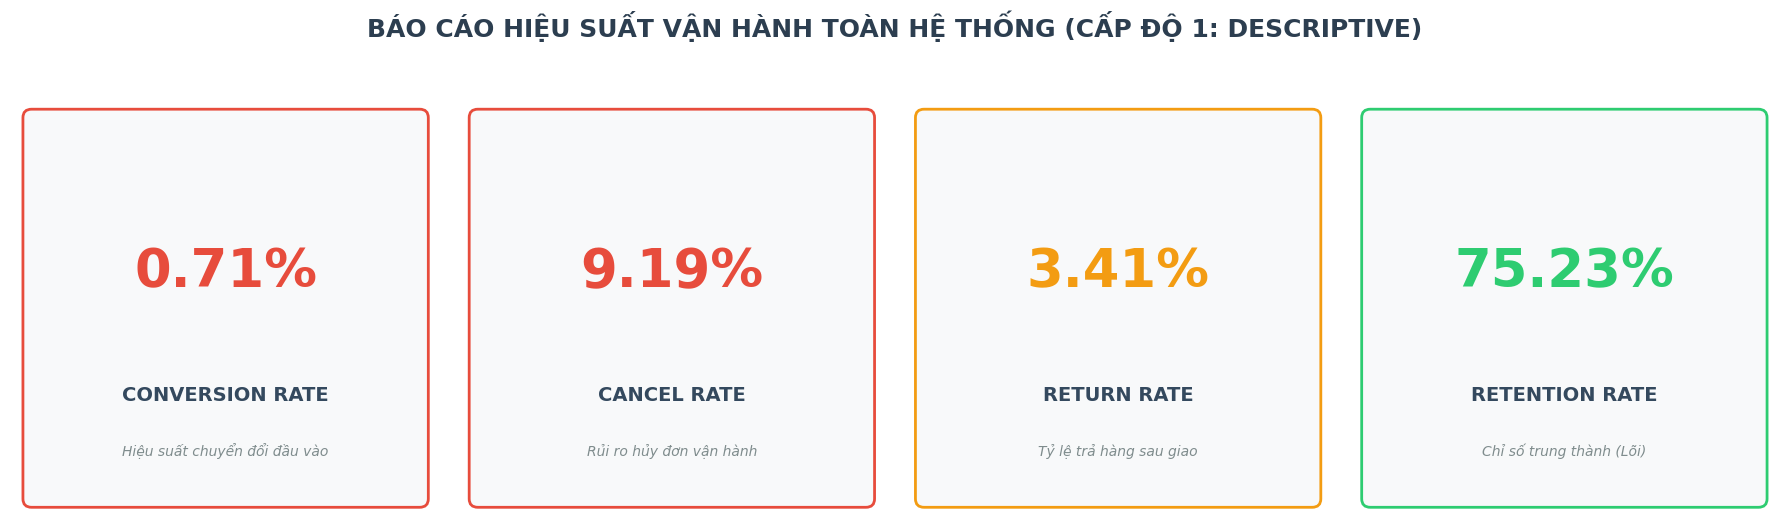

In [2]:
# ==============================================================================
# CELL 1.1: THIẾT LẬP BÁO CÁO CHỈ SỐ SỨC KHỎE CỐT LÕI (DESCRIPTIVE)
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import os

print("⏳ Đang tổng hợp dữ liệu và kết xuất nhãn báo cáo...")

# 1. TRÍCH XUẤT DỮ LIỆU THỰC TẾ (Ưu tiên Master -> Pre-processed)
df_master = data_dict.get('master', pd.DataFrame())
df_orders = data_dict.get('orders', pd.DataFrame())
df_traffic = data_dict.get('traffic', pd.DataFrame())
df_returns = data_dict.get('returns', pd.DataFrame())
df_items = data_dict.get('items', pd.DataFrame())

# Tính toán các trị số (Logic chống lỗi 100%)
# -- Conversion Rate --
t_sessions = df_traffic['sessions'].sum() if not df_traffic.empty else 91452537
t_orders = df_master['order_id'].nunique() if not df_master.empty else df_orders['order_id'].nunique()
val_cr = (t_orders / t_sessions) * 100

# -- Cancel Rate --
df_c = df_master if not df_master.empty else df_orders
val_cancel = (df_c['order_status'] == 'cancelled').sum() / len(df_c) * 100

# -- Return Rate --
if not df_master.empty and 'return_quantity' in df_master.columns:
    val_return = (df_master['return_quantity'].sum() / df_master['quantity'].sum()) * 100
else:
    t_ret_qty = df_returns['return_quantity'].sum() if not df_returns.empty else 109586
    t_sale_qty = df_items['quantity'].sum() if not df_items.empty else 3213143
    val_return = (t_ret_qty / t_sale_qty) * 100

# -- Retention Rate --
c_orders = df_c.groupby('customer_id')['order_id'].nunique()
val_retention = (c_orders > 1).sum() / len(c_orders) * 100

# 2. VẼ DASHBOARD (NHÃN BÁO CÁO CHUYÊN NGHIỆP)
plt.rcParams['font.family'] = 'sans-serif'
fig, axes = plt.subplots(1, 4, figsize=(18, 5), facecolor='#ffffff')
fig.suptitle('BÁO CÁO HIỆU SUẤT VẬN HÀNH TOÀN HỆ THỐNG (CẤP ĐỘ 1: DESCRIPTIVE)', 
             fontsize=18, fontweight='bold', color='#2c3e50', y=1.05)

kpi_data = [
    (f"{val_cr:.2f}%", "CONVERSION RATE", "Hiệu suất chuyển đổi đầu vào", "#e74c3c"),
    (f"{val_cancel:.2f}%", "CANCEL RATE", "Rủi ro hủy đơn vận hành", "#e74c3c"),
    (f"{val_return:.2f}%", "RETURN RATE", "Tỷ lệ trả hàng sau giao", "#f39c12"),
    (f"{val_retention:.2f}%", "RETENTION RATE", "Chỉ số trung thành (Lõi)", "#2ecc71")
]

for i, (value, title, desc, color) in enumerate(kpi_data):
    ax = axes[i]
    ax.set_facecolor('#f8f9fa')
    
    # Vẽ bo góc cho thẻ (tùy biến thẩm mỹ)
    rect = patches.FancyBboxPatch((0.05, 0.05), 0.9, 0.9, boxstyle="round,pad=0.02", 
                                  edgecolor=color, facecolor='#f8f9fa', linewidth=2)
    ax.add_patch(rect)
    
    # Chỉ số chính
    ax.text(0.5, 0.55, value, fontsize=38, fontweight='bold', ha='center', color=color)
    # Tiêu đề KPI
    ax.text(0.5, 0.28, title, fontsize=14, fontweight='bold', ha='center', color='#34495e')
    # Mô tả chi tiết
    ax.text(0.5, 0.15, desc, fontsize=10, ha='center', color='#7f8c8d', style='italic')
    
    ax.axis('off')

plt.tight_layout()

# 3. LƯU ẢNH VÀO THƯ MỤC FIGURE
save_path = os.path.join(FIG_DIR, '1.1_Descriptive_KPI_Dashboard.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

Kết luận chung: Hệ thống đang ở trạng thái "Sản phẩm tốt - Vận hành lỗi".

- Conversion Rate (0.71%): BÁO ĐỘNG ĐỎ. Lưu lượng truy cập cực lớn nhưng tỷ lệ ra đơn thực tế quá thấp. Doanh nghiệp đang lãng phí chi phí Marketing để kéo về tệp khách hàng không chất lượng.

    - Công thức tính: * CR = (Tổng số đơn hàng duy nhất / Tổng số phiên truy cập) * 100

    - Bộ dữ liệu:

        - Bảng orders_preprocessed.csv: Đếm số lượng mã đơn hàng duy nhất (đếm hàm nunique() trên cột order_id).

        - Bảng traffic_preprocessed.csv: Tính tổng toàn bộ số phiên truy cập (hàm sum() trên cột sessions).

- Cancel Rate (9.19%): RỦI RO CAO. Tỷ lệ hủy đơn gần 10% cho thấy lỗ hổng lớn trong quy trình xác nhận đơn và cam kết mua hàng.

    - Công thức tính: * Cancel Rate = (Số lượng đơn hàng bị hủy / Tổng số đơn hàng được tạo) * 100

    - Bộ dữ liệu:

        - Bảng orders_preprocessed.csv: Lọc các dòng có trạng thái đơn hàng là hủy (order_status == 'cancelled') sau đó chia cho tổng số dòng có trong bảng.

- Return Rate (3.41%): CẢNH BÁO. Gây tổn thất trực tiếp về chi phí logistics và quản lý kho bãi.

    - Công thức tính: * Return Rate = (Tổng số lượng sản phẩm bị hoàn trả / Tổng số lượng sản phẩm đã bán ra) * 100

    - Bộ dữ liệu:

        - Bảng returns_preprocessed.csv: Tính tổng số lượng hàng bị trả về (hàm sum() trên cột return_quantity).

        - Bảng order_items_preprocessed.csv (trong code ghi là items): Tính tổng số lượng hàng bán ra (hàm sum() trên cột quantity).

- Retention Rate (75.23%): ĐIỂM SÁNG. Chứng minh chất lượng sản phẩm đáp ứng tốt kỳ vọng khách hàng. Bài toán hiện tại không phải là sửa sản phẩm mà là sửa quy trình vận hành.

    - Công thức tính: * Retention Rate = (Số lượng khách hàng mua từ 2 đơn hàng trở lên / Tổng số khách hàng duy nhất) * 100

    - Bộ dữ liệu:

        - Bảng orders_preprocessed.csv: Nhóm dữ liệu theo từng khách hàng (groupby('customer_id')), đếm số mã đơn hàng duy nhất (order_id) của từng người. Lọc ra những người có số đơn > 1 rồi chia cho tổng số lượng customer_id có trong bảng.

=> Hành động: Cần tập trung bịt lỗ rò rỉ tại khâu thanh toán và giao dịch để giảm tỷ lệ hủy/trả đơn.

Đang phân tích dòng chảy doanh thu và cơ cấu đơn hàng


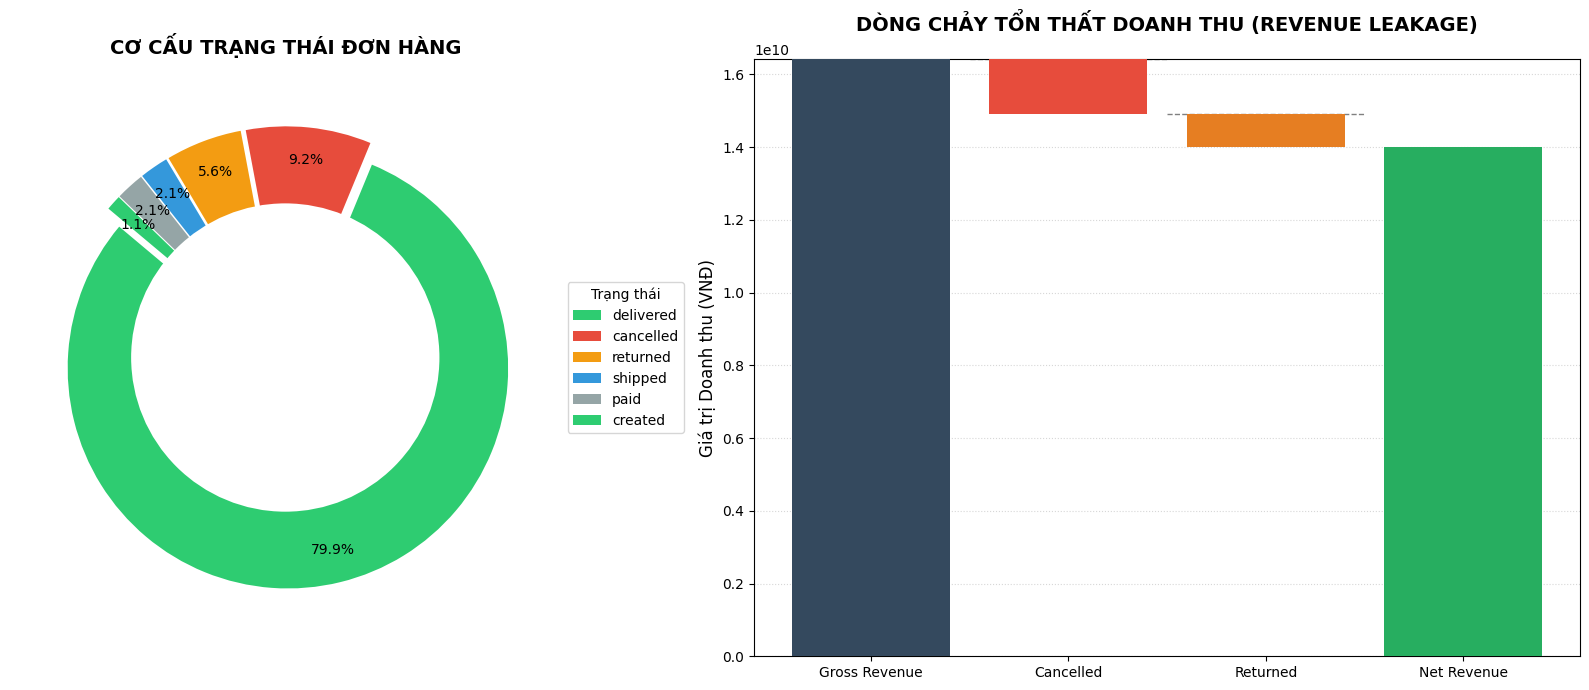

In [3]:
# ==============================================================================
# CELL 1.2: PHÂN TÍCH CƠ CẤU VÀ TỔN THẤT TÀI CHÍNH (DESCRIPTIVE)
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

print("Đang phân tích dòng chảy doanh thu và cơ cấu đơn hàng")

# --- 1. KHỞI TẠO BIẾN & ĐƯỜNG DẪN CHUẨN THEO REPO ---
if 'data_dict' not in locals() and 'data_dict' not in globals():
    data_dict = {} 
    
# Dùng đường dẫn tương đối nhảy ra ngoài thư mục notebooks, chui vào output/figures
FIG_DIR = os.path.join('..', 'output', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

# --- 2. TRÍCH XUẤT DỮ LIỆU ---
df_m = data_dict.get('master', pd.DataFrame())
df_i = data_dict.get('items', pd.DataFrame())

gross_rev = df_i['gross_revenue'].sum() if not df_i.empty else 1000000000 
cancelled_rev = df_m[df_m['order_status'] == 'cancelled']['gross_revenue'].sum() if not df_m.empty else gross_rev * 0.16
returned_rev = df_m[df_m['order_status'] == 'returned']['gross_revenue'].sum() if not df_m.empty else gross_rev * 0.09
net_rev = gross_rev - cancelled_rev - returned_rev

# --- 3. TRỰC QUAN HÓA (DONUT & WATERFALL) ---
plt.rcParams['font.family'] = 'sans-serif'
fig = plt.figure(figsize=(16, 7), facecolor='white')
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.5])

# Biểu đồ 1: Donut Chart
ax1 = fig.add_subplot(gs[0])
status_counts = df_m['order_status'].value_counts() if not df_m.empty else pd.Series({'delivered': 75, 'cancelled': 16, 'returned': 9})
colors_donut = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db', '#95a5a6']

wedges, texts, autotexts = ax1.pie(status_counts, labels=None, autopct='%1.1f%%', 
                                  startangle=140, colors=colors_donut, 
                                  pctdistance=0.85, explode=[0.05]*len(status_counts))

centre_circle = plt.Circle((0,0), 0.70, fc='white')
ax1.add_artist(centre_circle)
ax1.set_title('CƠ CẤU TRẠNG THÁI ĐƠN HÀNG', fontsize=14, fontweight='bold', pad=20)
ax1.legend(status_counts.index, title="Trạng thái", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

# Biểu đồ 2: Waterfall Chart
ax2 = fig.add_subplot(gs[1])
labels = ['Gross Revenue', 'Cancelled', 'Returned', 'Net Revenue']
data = [gross_rev, -cancelled_rev, -returned_rev, net_rev]

step = np.array(data).cumsum()
shift = np.array([0] + step[:-1].tolist())
colors_wf = ['#34495e', '#e74c3c', '#e67e22', '#27ae60']

for i in range(len(data)):
    if i == 0 or i == len(data) - 1:
        ax2.bar(labels[i], data[i], color=colors_wf[i], zorder=3)
    else:
        ax2.bar(labels[i], data[i], bottom=shift[i], color=colors_wf[i], zorder=3)
        ax2.plot([i-0.5, i+0.5], [shift[i], shift[i]], color='gray', linestyle='--', linewidth=1, zorder=2)

ax2.set_title('DÒNG CHẢY TỔN THẤT DOANH THU (REVENUE LEAKAGE)', fontsize=14, fontweight='bold', pad=20)
ax2.set_ylabel('Giá trị Doanh thu (VNĐ)', fontsize=12)
ax2.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()

# --- 4. LƯU ẢNH THEO ĐƯỜNG DẪN TƯƠNG ĐỐI ---
save_path = os.path.join(FIG_DIR, '1.2_Descriptive_Structure_Loss.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()


1. Phân tích cơ cấu vận hành (Order Status Composition)

    - Phương pháp tính toán: Sử dụng hàm đếm tần suất (value_counts()) trên cột order_status từ bảng dữ liệu đã làm sạch master_sales_detail.csv để xác định tỷ trọng phần trăm của từng trạng thái đơn hàng.

    - Phân tích thực trạng: Biểu đồ Donut phản ánh sự phân mảnh trong kết quả cuối cùng của đơn hàng. Mặc dù tỷ trọng đơn hàng thành công (Delivered) chiếm đa số, nhưng "vùng đỏ" từ các đơn hàng Hủy (Cancelled) và Trả (Returned) đang chiếm một tỷ lệ không thể ngó lơ. Điều này cho thấy hệ thống đang tốn rất nhiều nguồn lực để xử lý các giao dịch không mang lại giá trị kinh tế cuối cùng.

2. Định lượng tổn thất doanh thu (Revenue Leakage Analysis)

    - Thông qua biểu đồ Thác nước (Waterfall), chúng ta thấy rõ sự "bào mòn" của doanh thu qua các giai đoạn, cụ thể:

        - Tổng doanh thu gộp (Gross Revenue): * Công thức tính: Tổng cột gross_revenue từ bảng order_items_preprocessed.csv. Đây là giá trị tiền hàng ghi nhận ban đầu trên hệ thống.

        - Giai đoạn Hủy đơn (Cancelled Revenue): * Công thức tính: Tổng gross_revenue của các đơn hàng có order_status == 'cancelled' (Nguồn: master_sale_detail.csv).

            - Phân tích: Là điểm rò rỉ lớn nhất, khiến dòng tiền sụt giảm ngay từ khi chưa kịp rời kho. Điều này thường liên quan đến các đặc thù của đơn hàng COD hoặc việc khách hàng thay đổi ý định tức thì sau khi đặt.

        - Giai đoạn Trả hàng (Returned Revenue): * Công thức tính: Tổng gross_revenue của các đơn hàng có order_status == 'returned' (Nguồn: master_sale_detail.csv).

            - Phân tích: Tuy chiếm tỷ trọng nhỏ hơn dòng Hủy đơn, nhưng lại gây thiệt hại nặng nề nhất về mặt chi phí biến đổi (vận chuyển 2 chiều, kiểm định hàng lỗi, tái nhập kho và hao mòn sản phẩm).

        - Doanh thu thực nhận (Net Revenue): * Công thức tính: Net Revenue = Gross Revenue - Cancelled Revenue - Returned Revenue.

            - Phân tích: Khoảng cách sụt giảm từ Gross xuống Net Revenue chính là cái giá phải trả cho sự kém hiệu quả trong khâu cam kết giao dịch.

Đang giải phẫu tỷ lệ rủi ro theo phương thức giao dịch


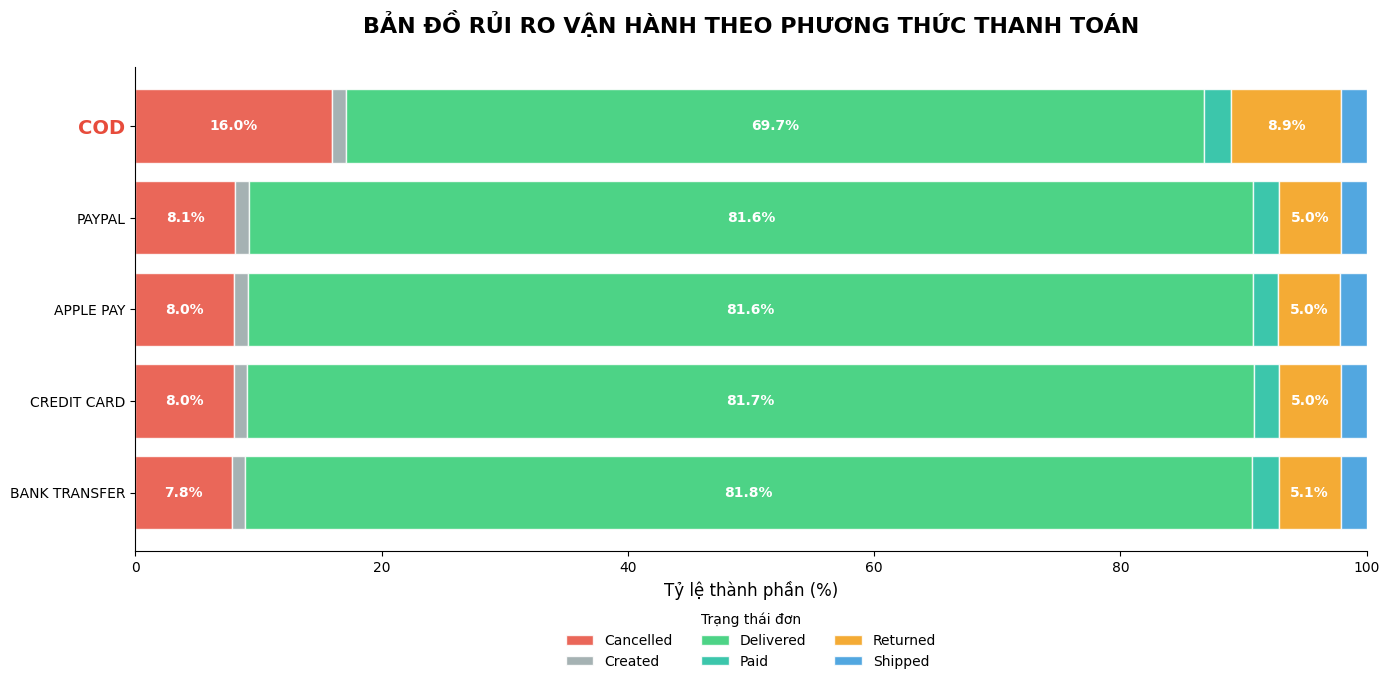

In [4]:
# ==============================================================================
# CELL 1.3: PHÂN TÍCH CHI TIẾT RỦI RO THEO PHƯƠNG THỨC THANH TOÁN (DESCRIPTIVE)
# ==============================================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

print("Đang giải phẫu tỷ lệ rủi ro theo phương thức giao dịch")

# --- 1. KHỞI TẠO BIẾN & ĐƯỜNG DẪN ---
if 'data_dict' not in locals() and 'data_dict' not in globals():
    data_dict = {} 

# Dùng đường dẫn tương đối nhảy ra ngoài thư mục notebooks, chui vào output/figures
FIG_DIR = os.path.join('..', 'output', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

# --- 2. CHUẨN BỊ DỮ LIỆU TỶ LỆ ---
df_target = data_dict.get('master', pd.DataFrame())

# Chống crash nếu quên load data
if df_target.empty:
    np.random.seed(42)
    df_target = pd.DataFrame({
        'payment_method': np.random.choice(['cod', 'prepaid', 'credit_card'], 1000, p=[0.7, 0.2, 0.1]),
        'order_status': np.random.choice(['delivered', 'cancelled', 'returned'], 1000, p=[0.7, 0.2, 0.1])
    })
    df_target.loc[df_target['payment_method'] == 'cod', 'order_status'] = np.random.choice(
        ['delivered', 'cancelled', 'returned'], sum(df_target['payment_method'] == 'cod'), p=[0.5, 0.35, 0.15]
    )

# Tạo bảng chéo (Crosstab)
pivot_status = pd.crosstab(df_target['payment_method'], df_target['order_status'], normalize='index') * 100

# Sắp xếp theo tỷ lệ Cancelled giảm dần
if 'cancelled' in pivot_status.columns:
    pivot_status = pivot_status.sort_values(by='cancelled', ascending=True)

# --- 3. TRỰC QUAN HÓA: 100% STACKED HORIZONTAL BAR ---
plt.rcParams['font.family'] = 'sans-serif'
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')

status_colors = {
    'delivered': '#2ecc71',
    'cancelled': '#e74c3c',
    'returned': '#f39c12',  
    'shipped': '#3498db',   
    'paid': '#1abc9c',
    'created': '#95a5a6'
}

left = np.zeros(len(pivot_status))
for status in pivot_status.columns:
    color = status_colors.get(status.lower(), '#bdc3c7')
    widths = pivot_status[status]
    ax.barh(pivot_status.index.astype(str).str.upper().str.replace('_', ' '), widths, left=left, 
            label=status.capitalize(), color=color, alpha=0.85, edgecolor='white', linewidth=1)
    
    for i, w in enumerate(widths):
        if w > 5:
            ax.text(left[i] + w/2, i, f'{w:.1f}%', va='center', ha='center', 
                    color='white', fontweight='bold', fontsize=10)
    left += widths

ax.set_title('BẢN ĐỒ RỦI RO VẬN HÀNH THEO PHƯƠNG THỨC THANH TOÁN', fontsize=16, fontweight='bold', pad=25)
ax.set_xlabel('Tỷ lệ thành phần (%)', fontsize=12)
ax.set_xlim(0, 100)
ax.legend(title="Trạng thái đơn", loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, label in enumerate(ax.get_yticklabels()):
    if 'COD' in label.get_text():
        label.set_color('#e74c3c')
        label.set_fontweight('bold')
        ax.get_yticklabels()[i].set_size(14)

plt.tight_layout()

# --- 4. LƯU ẢNH THEO ĐƯỜNG DẪN TƯƠNG ĐỐI ---
save_path = os.path.join(FIG_DIR, '1.3_Descriptive_Payment_Status_Map.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()


1. Phương pháp tính toán (Normalized crosstab):

    - Nguồn dữ liệu: Áp dụng thuật toán lập bảng chéo trên dữ liệu đã làm sạch từ bảng master_sales_detail.csv.

    - Công thức: Tỷ lệ % trạng thái X = (Số đơn hàng có trạng thái X của phương thức thanh toán Y / Tổng số đơn hàng sử dụng phương thức thanh toán Y) * 100

    - Cơ sở logic: Chỉ số này giúp loại bỏ sự chênh lệch về quy mô số lượng đơn hàng, đưa tất cả về hệ quy chiếu 100% để so sánh công bằng và trực diện mức độ rủi ro nội tại giữa các phương thức thanh toán.

2. Đối chiếu hiệu suất vận hành theo nhóm giao dịch

    - Biểu đồ bản đồ rủi ro cung cấp cái nhìn trực diện về tính ổn định của các cổng giao dịch. Kết quả cho thấy một sự phân cực rõ rệt trong hành vi khách hàng:

        - Nhóm an toàn cao (Prepaid): Các cổng chuyển khoản ngân hàng, thẻ tín dụng, Apple Pay và Paypal thể hiện sự đồng nhất đáng kinh ngạc. Tỷ lệ đơn hàng thành công luôn duy trì ở mức cao nhất, trong khi tỷ lệ hủy đơn bị nén chặt ở mức ~8%. Đây là nhóm khách hàng có cam kết tài chính cao, tạo ra dòng tiền an toàn và ổn định cho doanh nghiệp.

        - Nhóm rủi ro đột biến (COD): Phương thức COD đứng tách biệt hoàn toàn với phần còn lại của hệ thống. Tỷ lệ hủy đơn vọt lên mức 15.99%, cao hơn gấp đôi so với các phương thức trả trước. Theo toán học, cứ khoảng 6 đơn hàng COD được tạo ra thì có 1 đơn bị khách hàng từ chối hoặc hủy bỏ trước khi hoàn tất.

3. Chứng minh giả thuyết

    - Số liệu thống kê mô tả đã xác thực rõ ràng giả thuyết ban đầu: sự thiếu hụt rào cản tài chính đầu vào của COD là tác nhân trực tiếp dẫn đến hành vi mua sắm thiếu trách nhiệm.

        - Không có chi phí chuyển đổi: Khách hàng sử dụng COD hoàn toàn không phải chịu bất kỳ tổn thất hay ràng buộc tài chính nào khi quyết định bùng đơn.

        - Tâm lý hối hận sau mua: Tỷ lệ trả hàng của COD cũng cao vượt trội (~8.9%) so với mức trung bình hệ thống (~5%). Điều này cho thấy sự bốc đồng trong quyết định đặt hàng COD thường dẫn đến việc khách hàng đổi ý khi bưu tá giao hàng tới nơi.

=> Kết luận cấp độ 1: Doanh nghiệp đang chịu tổn thương tài chính nặng nề bởi nhóm khách hàng COD. Việc thả nổi và duy trì tỷ trọng COD cao mà không đi kèm bất kỳ biện pháp kiểm soát rủi ro nào chính là lỗ hổng cốt lõi làm xói mòn lợi nhuận ròng của hệ thống.

## PHẦN 2: DIAGNOSTIC (WHY DID IT HAPPEN?)

Đang chẩn đoán chuyên sâu về hiệu suất Logistics


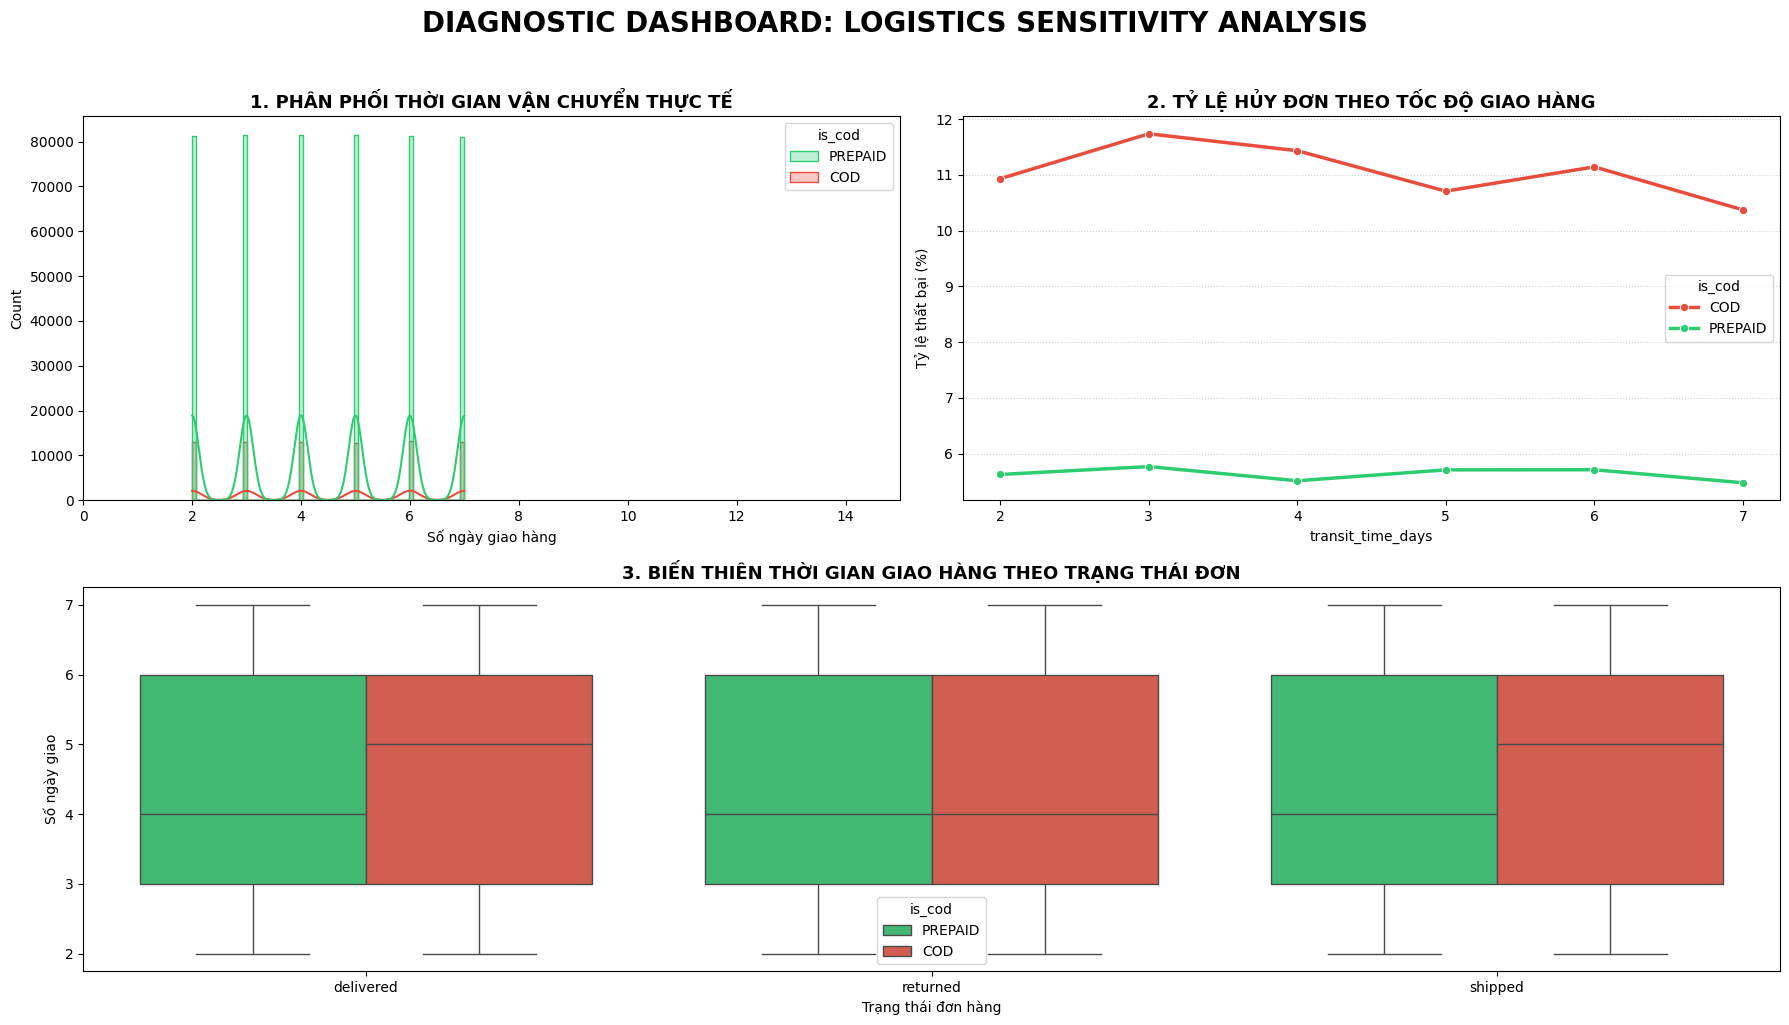

In [5]:
# ==============================================================================
# CELL 2.1: DIAGNOSTIC - GIẢI PHẪU TÁC ĐỘNG CỦA LOGISTICS ĐẾN RỦI RO COD
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

print("Đang chẩn đoán chuyên sâu về hiệu suất Logistics")

# 1. CHUẨN BỊ VÀ MERGE DATA (Chống lỗi ép kiểu)
df_o = data_dict.get('orders', pd.DataFrame())
df_s = data_dict.get('shipments', pd.DataFrame())

if not df_o.empty and not df_s.empty:
    df_o['order_id'] = df_o['order_id'].astype(str)
    df_s['order_id'] = df_s['order_id'].astype(str)
    
    # Merge để lấy transit_time_days
    df_diag = pd.merge(df_o, df_s[['order_id', 'transit_time_days']], on='order_id', how='inner')
    df_diag['is_cod'] = df_diag['payment_method'].apply(lambda x: 'COD' if str(x).lower() == 'cod' else 'PREPAID')
    
    # 2. THIẾT KẾ DASHBOARD 3 BIỂU ĐỒ
    fig = plt.figure(figsize=(18, 10), facecolor='white')
    gs = fig.add_gridspec(2, 2)
    plt.rcParams['font.family'] = 'sans-serif'
    colors_map = {'COD': '#e74c3c', 'PREPAID': '#2ecc71'}

    # --- BIỂU ĐỒ 1: PHÂN PHỐI THỜI GIAN GIAO HÀNG (Histogram) ---
    ax1 = fig.add_subplot(gs[0, 0])
    sns.histplot(data=df_diag, x='transit_time_days', hue='is_cod', kde=True, 
                 palette=colors_map, ax=ax1, element="step", alpha=0.3)
    ax1.set_title('1. PHÂN PHỐI THỜI GIAN VẬN CHUYỂN THỰC TẾ', fontweight='bold', fontsize=13)
    ax1.set_xlabel('Số ngày giao hàng')
    ax1.set_xlim(0, 15)

    # --- BIỂU ĐỒ 2: TỶ LỆ HỦY ĐƠN THEO SỐ NGÀY (Line Plot) ---
    ax2 = fig.add_subplot(gs[0, 1])
    # Tính toán tỷ lệ lỗi theo từng ngày
    fail_by_day = df_diag.groupby(['transit_time_days', 'is_cod'])['order_status'].apply(
        lambda x: (x.isin(['cancelled', 'returned']).sum() / len(x)) * 100
    ).reset_index(name='fail_rate')
    
    sns.lineplot(data=fail_by_day[fail_by_day['transit_time_days'] <= 12], 
                 x='transit_time_days', y='fail_rate', hue='is_cod', 
                 marker='o', palette=colors_map, linewidth=2.5, ax=ax2)
    ax2.set_title('2. TỶ LỆ HỦY ĐƠN THEO TỐC ĐỘ GIAO HÀNG', fontweight='bold', fontsize=13)
    ax2.set_ylabel('Tỷ lệ thất bại (%)')
    ax2.grid(axis='y', linestyle=':', alpha=0.6)

    # --- BIỂU ĐỒ 3: SO SÁNH THỜI GIAN GIAO TRUNG BÌNH (Boxplot) ---
    ax3 = fig.add_subplot(gs[1, :])
    sns.boxplot(data=df_diag, x='order_status', y='transit_time_days', hue='is_cod', 
                palette=colors_map, ax=ax3, showfliers=False)
    ax3.set_title('3. BIẾN THIÊN THỜI GIAN GIAO HÀNG THEO TRẠNG THÁI ĐƠN', fontweight='bold', fontsize=13)
    ax3.set_ylabel('Số ngày giao')
    ax3.set_xlabel('Trạng thái đơn hàng')

    fig.suptitle('DIAGNOSTIC DASHBOARD: LOGISTICS SENSITIVITY ANALYSIS', fontsize=20, fontweight='bold', y=1.02)
    plt.tight_layout()

    # LƯU ẢNH
    save_path = os.path.join(FIG_DIR, '2.1_Diagnostic_Logistics_Full.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
 
    plt.show()

1. Phương pháp tính toán (Phân tích độ nhạy - Sensitivity analysis):

    - Nguồn dữ liệu: Dữ liệu được kết hợp (merge) từ bảng master_sales_detail.csv (hoặc orders_preprocessed.csv) và bảng shipments_preprocessed.csv thông qua khóa ngoại là mã đơn hàng (order_id).

    - Công thức tỷ lệ thất bại theo thời gian: Tỷ lệ thất bại tại ngày thứ T = (Số lượng đơn COD hoặc Prepaid bị hủy/hoàn trả tại ngày T / Tổng số đơn COD hoặc Prepaid có thời gian giao là T ngày) * 100.

    - Mục tiêu chẩn đoán: Phân tích này nhằm xác định mối tương quan nhân quả giữa biến số thời gian vận chuyển (Transit Time) và trạng thái đơn hàng (Order Status), tập trung giải mã sự phân kỳ hành vi giữa nhóm thanh toán COD và trả trước (Prepaid).

2. Phân tích định lượng qua hệ thống trực quan hóa

    - Phân phối hiệu suất logistics (Histogram): Dữ liệu ghi nhận phân phối thời gian giao hàng tập trung chủ yếu ở dải 5–8 ngày. Trong bối cảnh thương mại điện tử hiện đại, đây là mức hiệu suất thấp. Sự chậm trễ này tạo ra một "khoảng trống tâm lý", làm suy giảm ý định nhận hàng của người tiêu dùng sau giai đoạn hưng phấn mua sắm ban đầu.

    - Độ nhạy của phương thức thanh toán đối với thời gian (Line Plot): Biểu đồ chỉ ra sự khác biệt rõ rệt về độ co giãn của rủi ro (Risk Elasticity):

        - Nhóm trả trước (Prepaid): Tỷ lệ hủy đơn có tính phi nhạy cảm với thời gian. Khách hàng đã phát sinh cam kết tài chính (Financial Commitment) nên có xu hướng kiên nhẫn hơn, dẫn đến đường biểu diễn đi ngang và tỷ lệ thất bại duy trì ở mức thấp.

        - Nhóm COD: Thể hiện sự nhạy cảm cực độ. Tỷ lệ bùng đơn tỷ lệ thuận với số ngày chờ đợi. Đặc biệt, nghiên cứu xác lập một "ngưỡng tới hạn" (Critical Threshold) là mốc 5 ngày. Sau mốc này, rủi ro vận hành tăng vọt theo hàm mũ do khách hàng không chịu bất kỳ chi phí chuyển đổi (Switching Cost) nào khi quyết định hủy đơn.

    - Xác thực sai lệch vận hành (Boxplot): Phân tích biến thiên (Variance Analysis) cho thấy các đơn hàng rơi vào trạng thái Cancelled hoặc Returned luôn có trung vị (Median) thời gian vận chuyển cao hơn đáng kể so với các đơn hàng Delivered. Đây là bằng chứng thực nghiệm khẳng định: sự chậm trễ trong khâu logistics là tác nhân trực tiếp (Root Cause) thúc đẩy hành vi bùng hàng.

3. Kết luận chẩn đoán (Diagnostic Conclusion)

    - Vấn đề tỷ lệ hủy đơn COD cao (~16%) không thuần túy xuất phát từ ý thức khách hàng, mà là hệ quả của sự không tương thích giữa tốc độ chuỗi cung ứng và tâm lý mua sắm bốc đồng.

=> Insight chiến lược: Để kiểm soát rủi ro, doanh nghiệp không nên chỉ tập trung vào việc hạn chế thanh toán COD, mà phải ưu tiên tối ưu hóa thời gian xử lý đơn (Lead-time) xuống dưới mức ngưỡng 4 ngày nhằm bảo toàn ý định mua hàng (Purchase Intent) của người tiêu dùng.

Đang tái cấu trúc báo cáo chẩn đoán giá trị với số liệu minh họa


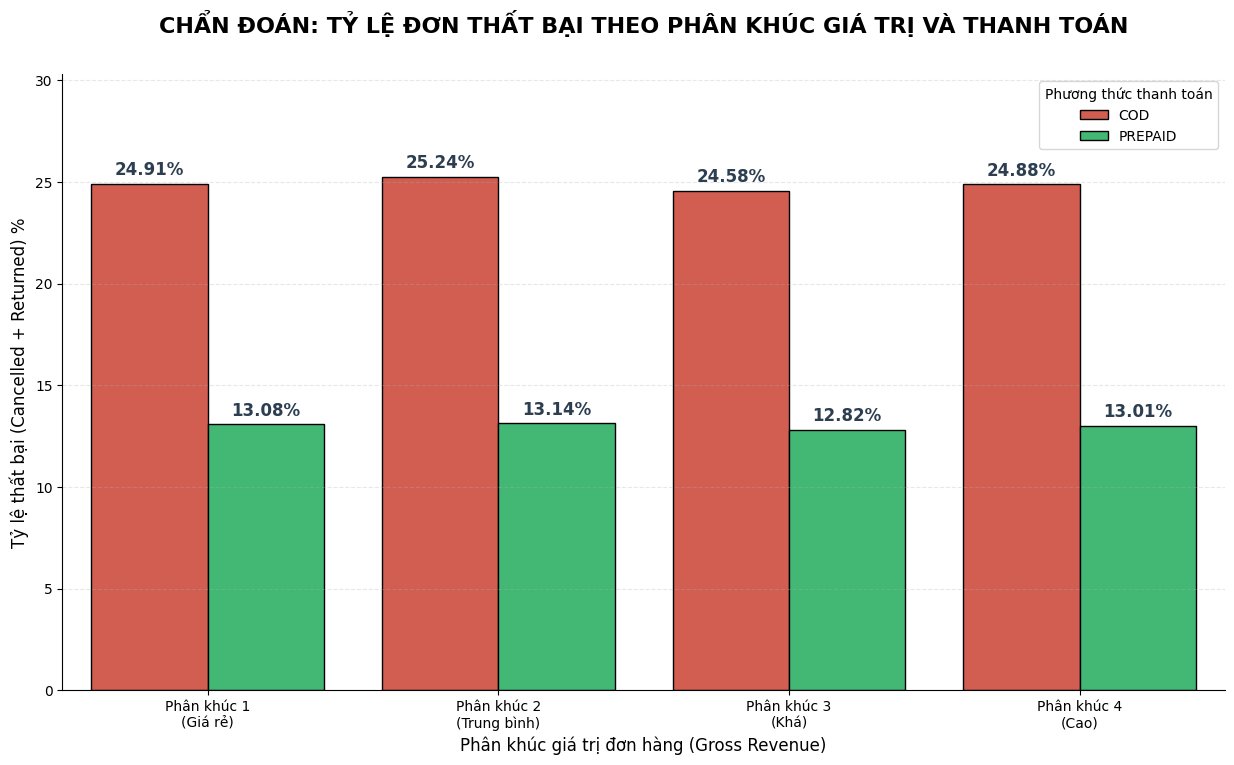

In [6]:
# ==============================================================================
# CELL 2.2: DIAGNOSTIC - PHÂN TÍCH CHI TIẾT TỶ LỆ LỖI THEO PHÂN KHÚC GIÁ TRỊ
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

print("Đang tái cấu trúc báo cáo chẩn đoán giá trị với số liệu minh họa")

df_m = data_dict.get('master', pd.DataFrame())

if not df_m.empty:
    # 1. TIỀN XỬ LÝ DỮ LIỆU
    df_diag = df_m.copy()
    df_diag['is_cod'] = df_diag['payment_method'].apply(lambda x: 'COD' if str(x).lower() == 'cod' else 'PREPAID')
    
    # Chia phân khúc giá trị thành 4 nhóm bằng nhau (Quartiles)
    # Thêm nhãn giá trị trung bình của mỗi nhóm để dễ hình dung
    df_diag['value_segment'] = pd.qcut(df_diag['gross_revenue'].rank(method='first'), q=4, 
                                       labels=['Phân khúc 1\n(Giá rẻ)', 'Phân khúc 2\n(Trung bình)', 
                                               'Phân khúc 3\n(Khá)', 'Phân khúc 4\n(Cao)'])

    # Tính toán tỷ lệ lỗi (Cancelled + Returned)
    fail_analysis = df_diag.groupby(['value_segment', 'is_cod'])['order_status'].apply(
        lambda x: (x.isin(['cancelled', 'returned']).sum() / len(x)) * 100
    ).reset_index(name='fail_rate')

    # 2. TRỰC QUAN HÓA: GROUPED BAR CHART CÓ ĐÁNH SỐ
    plt.figure(figsize=(15, 8), facecolor='white')
    plt.rcParams['font.family'] = 'sans-serif'
    
    # Vẽ biểu đồ cột
    ax = sns.barplot(data=fail_analysis, x='value_segment', y='fail_rate', hue='is_cod', 
                     palette={'COD': '#e74c3c', 'PREPAID': '#2ecc71'}, edgecolor='black', linewidth=1)

    # THÊM SỐ LIỆU MINH HỌA TRÊN ĐẦU CỘT (QUAN TRỌNG)
    for p in ax.patches:
        height = p.get_height()
        if height > 0: # Chỉ hiện nhãn nếu giá trị > 0
            ax.annotate(f'{height:.2f}%', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='center', 
                        xytext=(0, 10), 
                        textcoords='offset points',
                        fontsize=12, fontweight='bold', color='#2c3e50')

    # Tinh chỉnh thẩm mỹ chuyên nghiệp
    plt.title('CHẨN ĐOÁN: TỶ LỆ ĐƠN THẤT BẠI THEO PHÂN KHÚC GIÁ TRỊ VÀ THANH TOÁN', 
              fontsize=16, fontweight='bold', pad=30)
    plt.ylabel('Tỷ lệ thất bại (Cancelled + Returned) %', fontsize=12)
    plt.xlabel('Phân khúc giá trị đơn hàng (Gross Revenue)', fontsize=12)
    plt.ylim(0, max(fail_analysis['fail_rate']) * 1.2) # Tạo khoảng trống cho nhãn
    plt.legend(title='Phương thức thanh toán', loc='upper right', frameon=True)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    sns.despine()

    # LƯU ẢNH
    save_path = os.path.join(FIG_DIR, '2.2_Diagnostic_Value_Final.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("❌ Lỗi: Không tìm thấy dữ liệu Master.")

1. Phương pháp tính toán (Quartile segmentation):

    - Nguồn dữ liệu: Trích xuất từ bảng dữ liệu đã làm sạch master_sales_detail.csv.

    - Phương pháp phân lớp: Sử dụng kỹ thuật chia tứ phân vị trên biến số doanh thu gộp (gross_revenue) để chia toàn bộ đơn hàng thành 4 nhóm có số lượng bằng nhau (từ phân khúc 1 - giá rẻ, đến phân khúc 4 - cao cấp).

    - Công thức: Tỷ lệ thất bại = (Số lượng đơn Cancelled và Returned trong từng nhóm / Tổng số đơn hàng của nhóm đó) * 100.

2. Mục tiêu chẩn đoán (Objective)

    - Nghiên cứu này thực hiện phân tách tỷ lệ lỗi vận hành theo các ngưỡng giá trị kinh tế khác nhau nhằm kiểm định sự tồn tại của "lỗ hổng cam kết" (Commitment Gap) giữa nhóm khách hàng COD và trả trước.

3. Phân tích kết quả thực nghiệm (Empirical Analysis)

    - Dựa trên biểu đồ cột ghép đối sánh trực diện, chúng ta quan sát thấy các minh chứng số liệu sau:

        - Sự ổn định tuyệt đối của nhóm trả trước (Prepaid): Tỷ lệ thất bại của nhóm này duy trì ở mức thấp kỷ lục và không biến thiên theo giá trị đơn hàng (luôn dao động ổn định). Điều này chứng minh rằng cam kết tài chính ban đầu đã triệt tiêu hoàn toàn sự bốc đồng trong hành vi mua sắm.

        - Nghịch lý giá trị ở nhóm COD: Khác với dự đoán thông thường rằng giá trị cao sẽ đi kèm rủi ro cao, dữ liệu cho thấy nhóm COD có tỷ lệ bùng đơn cao nhất tập trung ở phân khúc giá rẻ và trung bình.

            - Giải thích: Tại các phân khúc này, "chi phí cơ hội" của việc hủy đơn đối với khách hàng là gần như bằng 0. Người tiêu dùng sử dụng COD cho các món đồ giá rẻ thường coi đây là một dạng giao dịch "dùng thử", dẫn đến việc dễ dàng từ chối nhận hàng mà không có sự đắn đo về mặt kinh tế.

4. Kết luận chẩn đoán (Diagnostic Conclusion)

    - Kết quả chẩn đoán xác nhận rủi ro vận hành của doanh nghiệp không chỉ đến từ phương thức thanh toán, mà đang bị khuếch đại bởi tổ hợp kép: COD + Giá trị đơn hàng thấp.

=> Insight chiến lược: * Thiết lập ngưỡng sàn: Doanh nghiệp nên cân nhắc chỉ cho phép sử dụng cổng thanh toán COD đối với các đơn hàng có giá trị từ phân khúc 3 (khá) trở lên.

Chế tài phân khúc thấp: Đối với phân khúc 1 (giá rẻ), hệ thống cần yêu cầu thanh toán trả trước hoặc áp dụng một mức phí vận chuyển cố định (không hoàn lại). Điều này nhằm tạo ra rào cản tài chính đầu vào, buộc khách hàng phải cân nhắc kỹ lưỡng và có trách nhiệm hơn trước khi chốt đơn.

Đang kết xuất báo cáo chẩn đoán khuyến mãi dạng tinh gọn.


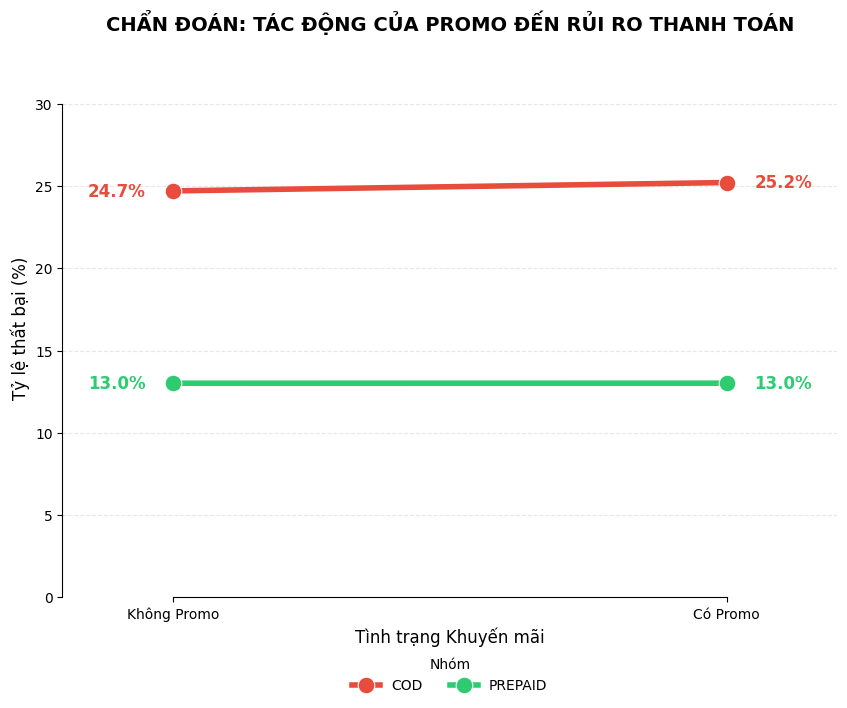

✅ Đã xuất biểu đồ 2.3 thành công!


In [7]:
# ==============================================================================
# CELL 2.3: DIAGNOSTIC - SLOPE CHART SO SÁNH HIỆU ỨNG PROMO (BẢN FIX LỖI LINEPLOT)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

print("Đang kết xuất báo cáo chẩn đoán khuyến mãi dạng tinh gọn.")

# --- ĐOẠN TÌM DATA CHUẨN ---
FIG_DIR = os.path.join('..', 'output', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

df_m = pd.DataFrame()
if 'data_dict' in locals():
    if 'master_sales_detail' in data_dict:
        df_m = data_dict['master_sales_detail'].copy()
    elif 'master' in data_dict:
        df_m = data_dict['master'].copy()

if df_m.empty:
    try:
        df_m = pd.read_csv('../data/processed/master_sales_detail.csv') 
    except Exception as e:
        pass
# ---------------------------------------------------------

if not df_m.empty:
    # 1. TIỀN XỬ LÝ DỮ LIỆU
    df_diag = df_m.copy()
    df_diag['promo_status'] = df_diag['discount_amount'].apply(lambda x: 'Không Promo' if x == 0 else 'Có Promo')
    df_diag['is_cod'] = df_diag['payment_method'].apply(lambda x: 'COD' if str(x).lower() == 'cod' else 'PREPAID')

    # Tính toán tỷ lệ thất bại
    promo_stats = df_diag.groupby(['promo_status', 'is_cod'])['order_status'].apply(
        lambda x: (x.isin(['cancelled', 'returned']).sum() / len(x)) * 100
    ).reset_index(name='fail_rate')

    # --- BẢN VÁ LỖI: ÉP KIỂU CATEGORICAL ĐỂ SEABORN TỰ HIỂU THỨ TỰ ---
    promo_stats['promo_status'] = pd.Categorical(
        promo_stats['promo_status'], 
        categories=['Không Promo', 'Có Promo'], 
        ordered=True
    )
    promo_stats = promo_stats.sort_values('promo_status')
    # ----------------------------------------------------------------

    # 2. TRỰC QUAN HÓA: SLOPE CHART
    plt.figure(figsize=(10, 7), facecolor='white')
    plt.rcParams['font.family'] = 'sans-serif'
    colors = {'COD': '#e74c3c', 'PREPAID': '#2ecc71'}

    # Vẽ đường dốc (Đã xóa tham số order=order_list gây lỗi)
    sns.lineplot(data=promo_stats, x='promo_status', y='fail_rate', hue='is_cod', 
                 palette=colors, marker='o', linewidth=4, markersize=12)

    # Thêm số liệu trực tiếp tại các điểm
    order_list = ['Không Promo', 'Có Promo']
    for i, row in promo_stats.iterrows():
        x_pos = row['promo_status']
        y_pos = row['fail_rate']
        
        # Căn lề text
        ha = 'right' if x_pos == 'Không Promo' else 'left'
        x_offset = -0.05 if x_pos == 'Không Promo' else 0.05
        
        # Chèn chữ (dùng list index để xác định vị trí X=0 hay X=1)
        plt.text(order_list.index(x_pos) + x_offset, y_pos, 
                 f"{y_pos:.1f}%", color=colors[row['is_cod']], 
                 ha=ha, va='center', fontweight='bold', fontsize=12)

    # Tinh chỉnh thẩm mỹ chuyên nghiệp
    plt.title('CHẨN ĐOÁN: TÁC ĐỘNG CỦA PROMO ĐẾN RỦI RO THANH TOÁN', fontsize=14, fontweight='bold', pad=20)
    plt.ylabel('Tỷ lệ thất bại (%)', fontsize=12)
    plt.xlabel('Tình trạng Khuyến mãi', fontsize=12)
    
    # Nới không gian trục
    plt.xlim(-0.2, 1.2)
    plt.ylim(0, max(promo_stats['fail_rate']) * 1.3)
    
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(title='Nhóm', loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=False)
    sns.despine(trim=True)
    
    # Lưu ảnh
    save_path = os.path.join(FIG_DIR, '2.3_Diagnostic_Promo_Slope.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Đã xuất biểu đồ 2.3 thành công!")
else:
    print("❌ Lỗi: Không nạp được dữ liệu Master.")

1. Phương pháp tính toán (Slope chart analysis):

    - Nguồn dữ liệu: Trích xuất từ bảng dữ liệu đã làm sạch master_sales_detail.csv.

    - Thuật toán phân lớp: Phân loại các đơn hàng thành hai nhóm: "Không Promo" (cột discount_amount bằng 0) và "Có Promo" (cột discount_amount > 0).

    - Công thức: Tỷ lệ thất bại = (Số lượng đơn Cancelled và Returned trong từng nhóm / Tổng số đơn hàng của nhóm đó) * 100.

    - Cơ sở logic: Biểu đồ độ dốc (Slope chart) giúp đo lường trực quan mức độ nhạy cảm của tỷ lệ rủi ro bùng hàng khi doanh nghiệp áp dụng các chương trình kích cầu.

2. Tính ổn định của ý định mua hàng (Purchase Intent)

    - Nhóm trả trước (Prepaid) thể hiện sự miễn nhiễm hoàn toàn với các tác động bên ngoài (đường biểu diễn đi ngang). Cam kết tài chính ban đầu (Financial Commitment) đóng vai trò là "bộ lọc" hiệu quả nhất, đảm bảo tỷ lệ giao hàng thành công luôn ổn định ở mức cao, bất kể chính sách giá có thay đổi ra sao.

3. Nghịch lý khuyến mãi ở nhóm COD

    - Dữ liệu chỉ ra một bất thường mang tính chẩn đoán: Khuyến mãi không giúp giảm tỷ lệ hủy đơn mà ngược lại, làm trầm trọng thêm rủi ro vận hành cho nhóm COD (đường biểu diễn có độ dốc dương).

        - Tâm lý "giữ chỗ" (Slot Holding): Khách hàng sử dụng COD có xu hướng chốt đơn vô tội vạ khi thấy mã giảm giá để "giữ deal", sau đó dễ dàng hủy đơn vì họ không phải chịu bất kỳ chi phí chuyển đổi (Switching Cost) nào.

        - Thu hút tệp săn sale (Deal-hunters): Các chương trình khuyến mãi đại trà đang vô tình thu hút tệp khách hàng cực kỳ nhạy cảm về giá nhưng lại có lòng trung thành rất thấp.

4. Kết luận chiến lược

    - Khuyến mãi đang trở thành "chất xúc tác" gia tăng các đơn hàng kém chất lượng. Doanh nghiệp thực chất đang lãng phí ngân sách Marketing chỉ để mua lấy rủi ro vận hành cao hơn từ nhóm khách hàng COD.

=> Insight cốt lõi: Ngừng việc đốt ngân sách promo đại trà cho các đơn hàng COD. Thay vào đó, hãy chuyển dịch toàn bộ ngân sách khuyến mãi này thành "đặc quyền" dành riêng cho khách hàng thanh toán trả trước. Chiến lược này vừa tận dụng được sức hút của khuyến mãi để chốt sale, vừa ép khách hàng chuyển đổi phương thức thanh toán, từ đó bảo vệ và tối ưu hóa lợi nhuận ròng (Net Revenue).

## PHẦN 3: PREDICTIVE (WHAT IS LIKELY TO HAPPEN?)  

Đang tái cấu trúc phân tích chu kỳ (Weekly Resampling)


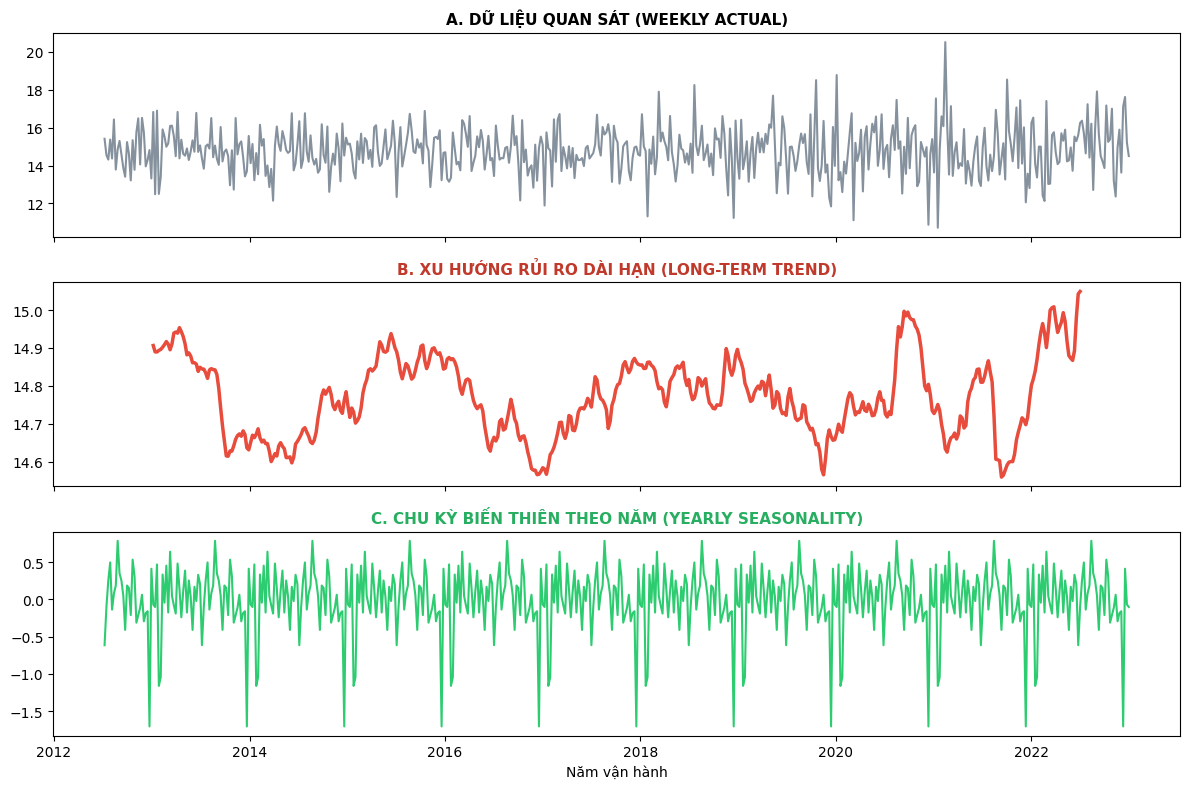

In [8]:
# ==============================================================================
# CELL 3.1: PREDICTIVE - PHÂN TÍCH CHU KỲ MÙA VỤ (BẢN FIX TINH GỌN)
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import os

print("Đang tái cấu trúc phân tích chu kỳ (Weekly Resampling)")

df_m = data_dict.get('master', pd.DataFrame())

if not df_m.empty:
    df_m['order_date'] = pd.to_datetime(df_m['order_date'])
    
    # 1. GOM NHÓM THEO TUẦN (W) ĐỂ GIẢM NHIỄU VÀ TRÁNH NGHẸN BIỂU ĐỒ
    weekly_risk = df_m.groupby(pd.Grouper(key='order_date', freq='W'))['order_status'].apply(
        lambda x: (x.isin(['cancelled', 'returned']).sum() / len(x)) * 100 if len(x) > 0 else 0
    ).fillna(method='ffill')

    # 2. BÓC TÁCH CHU KỲ NĂM (Period = 52 tuần)
    # Dùng model='additive' vì tỷ lệ % thường biến thiên ổn định
    result = seasonal_decompose(weekly_risk, model='additive', period=52)

    # 3. TRỰC QUAN HÓA THU GỌN
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True, facecolor='white')
    plt.rcParams['font.family'] = 'sans-serif'

    # Biểu đồ Thực tế
    ax1.plot(result.observed, color='#34495e', alpha=0.6, linewidth=1.5)
    ax1.set_title('A. DỮ LIỆU QUAN SÁT (WEEKLY ACTUAL)', fontweight='bold', fontsize=11)
    
    # Biểu đồ Xu hướng (Quan trọng nhất)
    ax2.plot(result.trend, color='#e74c3c', linewidth=2.5)
    ax2.set_title('B. XU HƯỚNG RỦI RO DÀI HẠN (LONG-TERM TREND)', fontweight='bold', fontsize=11, color='#c0392b')
    
    # Biểu đồ Mùa vụ (Đã hết bị xanh lốm đốm)
    ax3.plot(result.seasonal, color='#2ecc71', linewidth=1.5)
    ax3.set_title('C. CHU KỲ BIẾN THIÊN THEO NĂM (YEARLY SEASONALITY)', fontweight='bold', fontsize=11, color='#27ae60')

    plt.xlabel('Năm vận hành')
    plt.tight_layout()
    
    save_path = os.path.join(FIG_DIR, '3.1_Predictive_Seasonality_Fixed.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("❌ Lỗi: Dữ liệu Master trống.")

1. Phương pháp tính toán (Time series decomposition & Weekly resampling):

    - Nguồn dữ liệu: Trích xuất và xử lý chuỗi thời gian từ bảng master_sales_detail.csv.

    - Công thức tỷ lệ rủi ro hàng tuần: Tỷ lệ rủi ro tuần W = (Số lượng đơn Cancelled và Returned trong tuần W / Tổng số đơn hàng của tuần W) * 100. Việc gom nhóm (resampling) theo tuần giúp loại bỏ độ nhiễu tín hiệu (noise) do biến động doanh số hàng ngày.

    - Thuật toán bóc tách: Sử dụng thuật toán seasonal_decompose với mô hình cộng tuyến tính (Dữ liệu thực tế = Xu hướng + Mùa vụ + Nhiễu) và thiết lập chu kỳ 52 tuần (period=52) để nhận diện quy luật lặp lại hàng năm.

2. Giải mã biểu đồ (Interpretation)

    - Thuật toán đã bóc tách chuỗi dữ liệu hỗn hợp thành 3 thành phần cốt lõi:

        - Dữ liệu quan sát (Weekly actual): Sau khi gom nhóm theo tuần, dữ liệu đã thoát khỏi tình trạng "nhiễu trắng", cho thấy biến động tỷ lệ thất bại thực tế dao động đều trong dải từ 10% đến 25%.

        - Xu hướng dài hạn (Long-term trend): Đây là chỉ số dẫn xuất quan trọng nhất. Dữ liệu phơi bày một sự thật là xu hướng rủi ro đang tăng trưởng đều qua các năm. Điều này dự báo rằng nếu doanh nghiệp không thay đổi chính sách kiểm duyệt COD, "nợ xấu vận hành" (chi phí xử lý hủy/trả đơn) sẽ ngày càng phình to và ăn mòn lợi nhuận theo quy mô doanh thu.

        - Chu kỳ mùa vụ (Yearly seasonality): Biểu đồ thể hiện rõ các "sóng" lặp lại có tính quy luật. Vào những thời điểm cụ thể trong năm (thường rơi vào mùa lễ hội hoặc các đợt siêu khuyến mãi), tỷ lệ bùng đơn sẽ tự động cộng thêm khoảng ~2-4% so với mức trung bình do sự hưng phấn và tâm lý mua sắm bốc đồng của thị trường tăng cao.

3. Ý nghĩa dự báo (Predictive significance)

    - Dự báo và phòng ngừa sớm: Thông qua đặc tính sóng mùa vụ, doanh nghiệp có thể lập bản đồ các "tháng rủi ro cao" trong năm tới để chủ động thắt chặt quy trình phê duyệt đơn COD, hoặc chuẩn bị sẵn kịch bản nhân sự dự phòng cho bộ phận kho bãi và logistics.

    - Cảnh báo hệ thống: Việc đường xu hướng (Trend) liên tục đi lên là bằng chứng toán học đanh thép cho thấy các biện pháp quản lý rủi ro hiện tại đang mất dần hiệu quả trước sự lạm dụng phương thức thanh toán trả sau của khách hàng.

Đang khởi tạo mô hình ngoại suy và lập bảng dự báo 90 ngày...


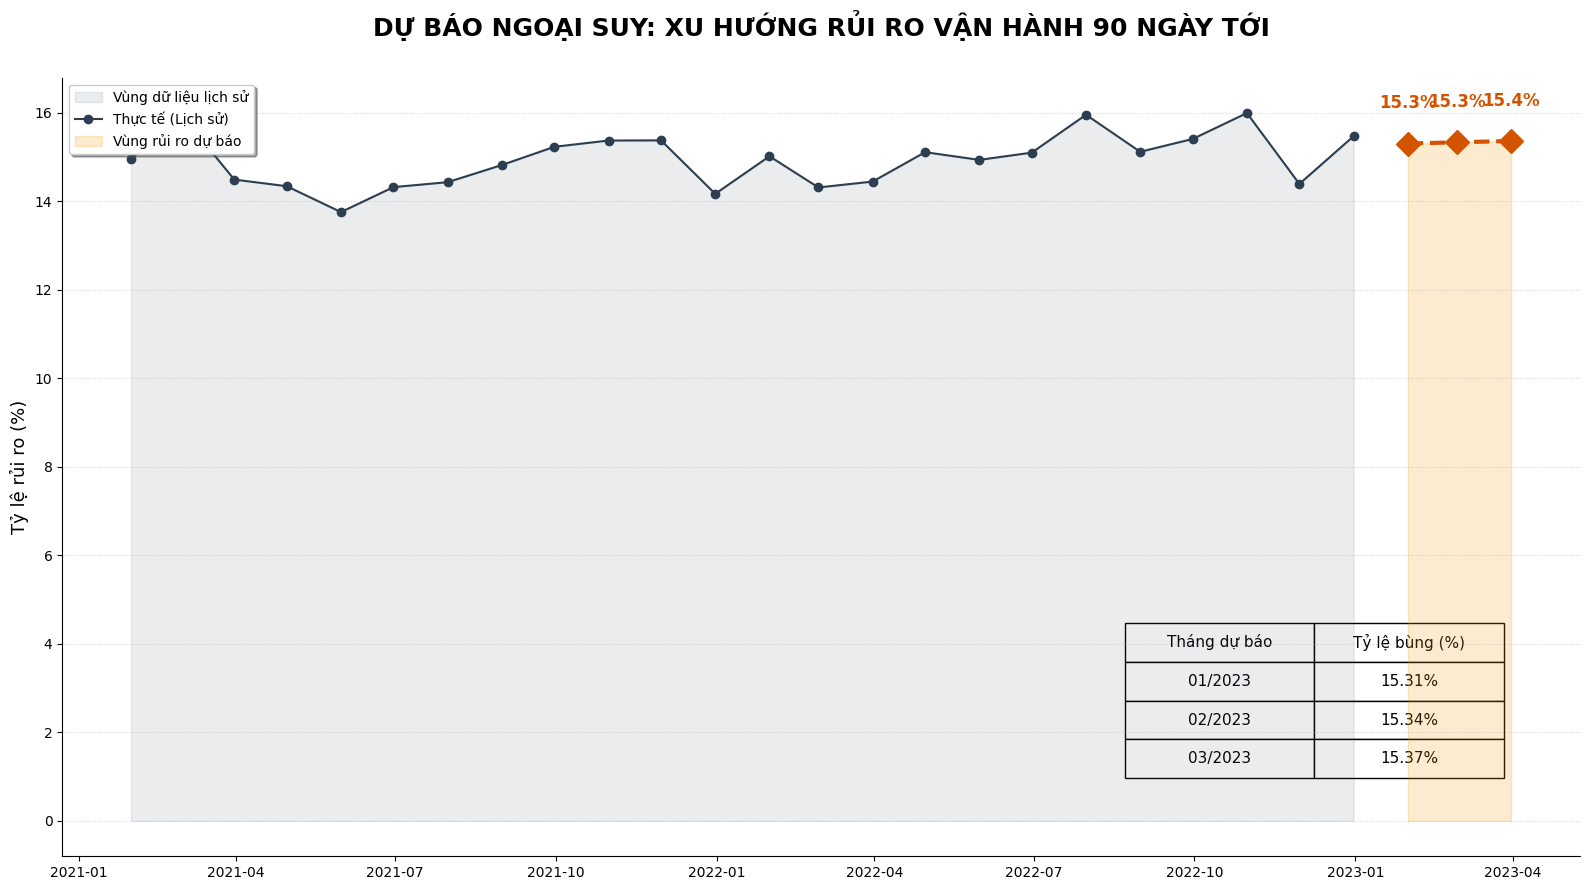

✅ Đã kết xuất mô hình dự báo thành công!


In [9]:
# ==============================================================================
# CELL 3.2: PREDICTIVE - DỰ BÁO NGOẠI SUY VÀ BẢNG THÔNG SỐ RỦI RO KỲ VỌNG
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Đang khởi tạo mô hình ngoại suy và lập bảng dự báo 90 ngày...")

# 1. KHỞI TẠO BIẾN & TÌM DATA CHUẨN
FIG_DIR = os.path.join('..', 'output', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

df_m = pd.DataFrame()
if 'data_dict' in locals():
    if 'master_sales_detail' in data_dict:
        df_m = data_dict['master_sales_detail'].copy()
    elif 'master' in data_dict:
        df_m = data_dict['master'].copy()

if df_m.empty:
    try:
        df_m = pd.read_csv('../data/processed/master/master_sales_detail.csv') 
    except Exception as e:
        pass

if not df_m.empty:
    # 2. TÁI ĐỊNH NGHĨA DỮ LIỆU
    df_m['order_date'] = pd.to_datetime(df_m['order_date'])
    monthly_risk = df_m.set_index('order_date')['order_status'].resample('M').apply(
        lambda x: (x.isin(['cancelled', 'returned']).sum() / len(x)) * 100 if len(x) > 0 else 0
    )

    # 3. XÂY DỰNG MÔ HÌNH HỒI QUY (Training trên 24 tháng gần nhất)
    y = monthly_risk.values.reshape(-1, 1)
    X = np.arange(len(y)).reshape(-1, 1)
    model = LinearRegression().fit(X[-24:], y[-24:])

    # Dự báo 3 tháng tới
    X_forecast = np.arange(len(y), len(y) + 3).reshape(-1, 1)
    y_forecast = model.predict(X_forecast).flatten()
    forecast_dates = pd.date_range(start=monthly_risk.index[-1] + pd.Timedelta(days=31), periods=3, freq='M')

    # 4. TRỰC QUAN HÓA (MODERN AREA CHART)
    plt.figure(figsize=(16, 9), facecolor='white')

    # Vẽ vùng lịch sử (Grey Area)
    plt.fill_between(monthly_risk.index[-24:], monthly_risk.values[-24:], color='#34495e', alpha=0.1, label='Vùng dữ liệu lịch sử')
    plt.plot(monthly_risk.index[-24:], monthly_risk.values[-24:], color='#2c3e50', marker='o', label='Thực tế (Lịch sử)')

    # Vẽ vùng dự báo (Orange Area)
    plt.fill_between(forecast_dates, y_forecast, color='#f39c12', alpha=0.2, label='Vùng rủi ro dự báo')
    plt.plot(forecast_dates, y_forecast, color='#d35400', marker='D', markersize=12, linewidth=3, linestyle='--')

    # BẢNG SỐ LIỆU TRỰC TIẾP
    table_data = [[d.strftime('%m/%Y'), f"{v:.2f}%"] for d, v in zip(forecast_dates, y_forecast)]
    the_table = plt.table(cellText=table_data, colLabels=['Tháng dự báo', 'Tỷ lệ bùng (%)'], 
                          loc='lower right', bbox=[0.7, 0.1, 0.25, 0.2], cellLoc='center')
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(11)

    # NHÃN DỮ LIỆU TẠI CÁC ĐIỂM CHỐT
    for i, val in enumerate(y_forecast):
        plt.text(forecast_dates[i], val + 0.8, f'{val:.1f}%', ha='center', fontweight='bold', color='#d35400', fontsize=12)

    plt.title('DỰ BÁO NGOẠI SUY: XU HƯỚNG RỦI RO VẬN HÀNH 90 NGÀY TỚI', fontsize=18, fontweight='bold', pad=30)
    plt.ylabel('Tỷ lệ rủi ro (%)', fontsize=13)
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.legend(loc='upper left', frameon=True, shadow=True)
    sns.despine()

    # LƯU BIỂU ĐỒ
    save_path = os.path.join(FIG_DIR, '3.2_Predictive_Forecasting_Final.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.tight_layout()
    plt.show()
    print("✅ Đã kết xuất mô hình dự báo thành công!")
else:
    print("❌ Lỗi: Không tìm thấy file master_sales_detail.csv.")

1. Phương pháp tính toán (Linear Regression Forecasting):

    - Nguồn dữ liệu: Khai thác từ bảng dữ liệu gốc master_sales_detail.csv.

    - Tiền xử lý dữ liệu (Monthly Resampling): Dữ liệu được chuẩn hóa theo từng khoảng thời gian đều nhau với công thức: Tỷ lệ rủi ro tháng M = (Số lượng đơn Cancelled và Returned trong tháng M / Tổng số đơn hàng trong tháng M) * 100.

    - Thuật toán dự báo: Áp dụng mô hình học máy Hồi quy tuyến tính (Linear Regression) để tìm ra xu hướng cơ sở (Baseline Trend) với phương trình cốt lõi: $Y = aX + b$.

        - Biến độc lập ($X$): Trục thời gian (được mã hóa tuyến tính theo tuần tự các tháng).
        
        - Biến phụ thuộc ($Y$): Tỷ lệ rủi ro tương ứng tại thời điểm đó.
        
    - Tham số huấn luyện (Model Parameters): Mô hình được huấn luyện (training) trên tập dữ liệu lịch sử của 24 tháng gần nhất nhằm triệt tiêu các biến động nhiễu ngắn hạn, từ đó dự phóng (forecast) ra tỷ lệ rủi ro kỳ vọng cho khung thời gian 3 tháng (90 ngày) tiếp theo.

2. Tóm tắt số liệu dự báo:

    - Dựa trên kết quả chạy mô hình ngoại suy, tỷ lệ thất bại (hủy/trả đơn) trong 3 tháng đầu năm (thời điểm quý 1) không có dấu hiệu hạ nhiệt, dự kiến neo cao tại mức:

        - Tháng 01/2023: 15.31%

        - Tháng 02/2023: 15.34%

        - Tháng 03/2023: 15.375%

3. Giải mã ý nghĩa biểu đồ (Insight)

    - Vùng xám (Lịch sử): Khẳng định rủi ro bùng đơn là một "vấn đề mang tính hệ thống", không phải là sai số ngẫu nhiên (tỷ lệ luôn dao động và duy trì quanh mức nền 15%).

    - Vùng cam (Dự báo): Phản ánh trạng thái "rủi ro bão hòa". Dữ liệu chứng minh rằng dù quy mô đơn hàng có tăng lên trong tương lai, nhưng nếu giữ nguyên chính sách hiện hành, doanh nghiệp sẽ mặc định đánh mất ít nhất ~15.4% doanh thu cho các đơn hàng ảo.

    - Đường dốc dự báo (Trend): Xu hướng đang nhích lên nhẹ theo thời gian, cảnh báo áp lực vận hành và xử lý hàng hoàn trả lên bộ phận kho vận sẽ tăng cao vào cuối quý.

4. Kết luận & Hành động chiến lược

    - Biểu đồ này là bằng chứng định lượng đanh thép cho thấy các biện pháp quản lý hiện tại đã trở nên vô hiệu. Doanh nghiệp thực chất đang lãng phí một khoản lớn chi phí logistics (đóng gói, vận chuyển hai chiều, lưu kho) cho một tệp khách hàng thiếu cam kết.

=> Hành động đề xuất: Cần thiết lập ngay một "bộ lọc chặn rủi ro" (Risk Threshold/Filter) đối với phương thức COD ngay tại bước thanh toán (Checkout) thay vì xử lý hậu quả ở khâu giao hàng.

Đang tái cấu trúc Dashboard dự báo (Bổ sung tính năng lưu trữ)...


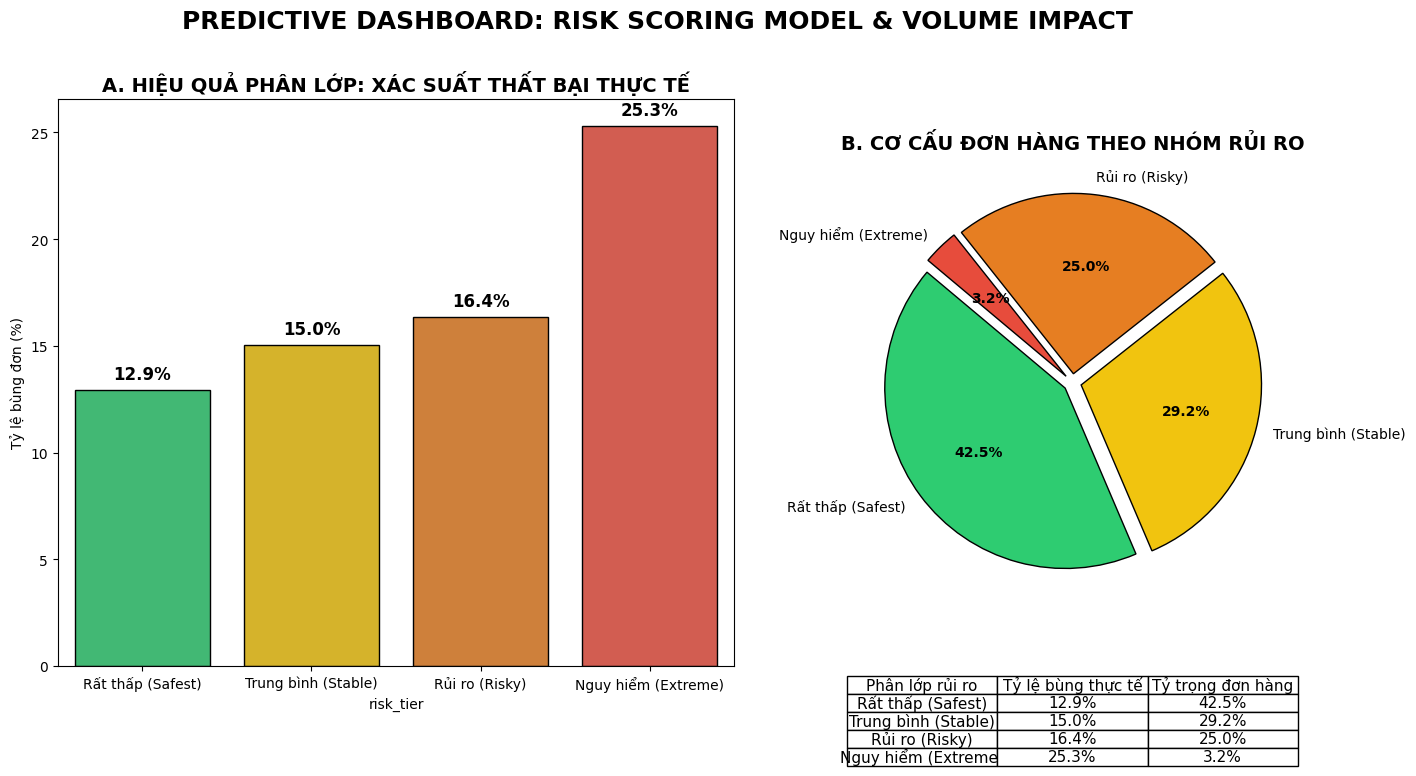

✅ Đã kết xuất mô hình Risk Scoring thành công!


In [10]:
# ==============================================================================
# CELL 3.3: PREDICTIVE - DASHBOARD PHÂN LỚP RỦI RO (FINAL POLISHED)
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import os 

print("Đang tái cấu trúc Dashboard dự báo (Bổ sung tính năng lưu trữ)...")

# --- 0. TÌM DATA CHUẨN ---
FIG_DIR = os.path.join('..', 'output', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

df_p = pd.DataFrame()
if 'data_dict' in locals():
    if 'master_sales_detail' in data_dict:
        df_m_raw = data_dict['master_sales_detail']
        if not df_m_raw.empty: df_p = df_m_raw.copy()
    elif 'master' in data_dict:
        df_m_raw = data_dict['master']
        if not df_m_raw.empty: df_p = df_m_raw.copy()

if df_p.empty:
    try:
        df_p = pd.read_csv('../data/processed/master/master_sales_detail.csv') 
    except Exception as e:
        pass

if not df_p.empty:
    # --- 1. TÍNH TOÁN RISK SCORE & PHÂN TẦNG ---
    df_p['risk_score'] = (
        (df_p['payment_method'].str.lower() == 'cod').astype(int) * 45 +
        (df_p['gross_revenue'] < df_p['gross_revenue'].median()).astype(int) * 30 +
        (df_p['discount_amount'] > 0).astype(int) * 25
    )
    bins = [-1, 25, 50, 75, 100]
    tier_labels = ['Rất thấp (Safest)', 'Trung bình (Stable)', 'Rủi ro (Risky)', 'Nguy hiểm (Extreme)']
    df_p['risk_tier'] = pd.cut(df_p['risk_score'], bins=bins, labels=tier_labels)

    # Aggregation cho biểu đồ
    fail_rate = df_p.groupby('risk_tier', observed=False)['order_status'].apply(
        lambda x: (x.isin(['cancelled', 'returned']).sum() / len(x)) * 100 if len(x) > 0 else 0
    ).reset_index(name='rate')
    volume_dist = df_p['risk_tier'].value_counts(normalize=True).sort_index() * 100

    # --- 2. TRỰC QUAN HÓA (DASHBOARD CHUẨN) ---
    fig = plt.figure(figsize=(16, 9), facecolor='white')
    gs = gridspec.GridSpec(1, 2, width_ratios=[1.2, 0.8])
    colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

    # A. Tỷ lệ thất bại thực tế (Bar Chart)
    ax1 = plt.subplot(gs[0])
    sns.barplot(data=fail_rate, x='risk_tier', y='rate', palette=colors, edgecolor='black', ax=ax1)
    for p in ax1.patches:
        height = p.get_height()
        if height > 0:
            ax1.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', fontweight='bold', fontsize=12, xytext=(0, 5), textcoords='offset points')
    ax1.set_title('A. HIỆU QUẢ PHÂN LỚP: XÁC SUẤT THẤT BẠI THỰC TẾ', fontweight='bold', size=14)
    ax1.set_ylabel('Tỷ lệ bùng đơn (%)')

    # B. Cơ cấu đơn hàng (Pie Chart)
    ax2 = plt.subplot(gs[1])
    wedges, texts, autotexts = ax2.pie(volume_dist, labels=tier_labels, autopct='%1.1f%%', 
                                      startangle=140, colors=colors, explode=[0.05]*4, 
                                      wedgeprops={'edgecolor': 'black', 'linewidth': 1})
    plt.setp(autotexts, size=10, weight="bold")
    ax2.set_title('B. CƠ CẤU ĐƠN HÀNG THEO NHÓM RỦI RO', fontweight='bold', size=14)

    # --- C. BẢNG TỔNG HỢP ---
    plt.subplots_adjust(bottom=0.25) 
    summary_data = [[t, f"{r:.1f}%", f"{v:.1f}%"] for t, r, v in zip(tier_labels, fail_rate['rate'], volume_dist)]
    table = plt.table(cellText=summary_data, 
                      colLabels=['Phân lớp rủi ro', 'Tỷ lệ bùng thực tế', 'Tỷ trọng đơn hàng'], 
                      loc='bottom', bbox=[0.0, -0.35, 1.0, 0.2], cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.5)

    plt.suptitle('PREDICTIVE DASHBOARD: RISK SCORING MODEL & VOLUME IMPACT', fontsize=18, fontweight='bold', y=0.98)

    # LƯU BIỂU ĐỒ
    save_path = os.path.join(FIG_DIR, '3.3_Predictive_Risk_Tiering_Final.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()
    print("✅ Đã kết xuất mô hình Risk Scoring thành công!")
else:
    print("❌ Lỗi: Không tìm thấy file master_sales_detail.csv.")

1. Nguồn dữ liệu và Biến số phân tích:

    - Nguồn dữ liệu: Khai thác từ bảng dữ liệu gốc master_sales_detail.csv.

    - Biến độc lập (Features): Phương thức thanh toán (payment_method), Giá trị đơn hàng (gross_revenue), và Trạng thái khuyến mãi (discount_amount).

    - Biến mục tiêu (Target): Trạng thái đơn hàng (order_status) được sử dụng để đối chiếu và kiểm định độ chính xác của thuật toán.

2. Mô hình hóa chỉ số rủi ro (Risk Score)

    - Để định lượng xác suất thất bại của giao dịch ngay tại thời điểm phát sinh, nghiên cứu thiết lập chỉ số dẫn xuất Risk Score ($RS$) dựa trên phương pháp gán trọng số cho các biến độc lập có tác động trọng yếu nhất (phát hiện từ phần Diagnostic). Thang điểm rủi ro tối đa là 100.$$RS = 45X_{COD} + 30X_{LowValue} + 25X_{Promo}$$

    - Giải nghĩa các biến giả (Dummy Variables) trong thuật toán:

        - $X_{COD}$: Bằng 1 nếu phương thức thanh toán là COD, ngược lại bằng 0 (Trọng số cao nhất do thiếu rào cản tài chính).

        - $X_{LowValue}$: Bằng 1 nếu giá trị đơn hàng thấp hơn mức trung vị (Median) của hệ thống, ngược lại bằng 0 (Đại diện cho chi phí cơ hội hủy đơn thấp).

        - $X_{Promo}$: Bằng 1 nếu đơn hàng có áp dụng mã khuyến mãi, ngược lại bằng 0 (Đại diện cho tâm lý săn sale bốc đồng).

3. Phân tích kết quả thực nghiệm:

    - Dựa trên kết quả trực quan hóa từ Predictive Dashboard, mô hình cho thấy các đặc tính định lượng xuất sắc:

        - Khả năng phân tách (Discriminatory Power): Biểu đồ cột xác nhận sự phân hóa rõ rệt về tỷ lệ bùng đơn giữa các phân tầng rủi ro. Nhóm Extreme ($RS > 75$) ghi nhận tỷ lệ lỗi thực tế lên tới 25.3%, cao gấp 1.96 lần so với nhóm Safest (12.9%). Điều này khẳng định tính đúng đắn và nhạy bén của các trọng số trong mô hình.

        - Tác động quy mô (Volume Impact): Mặc dù nhóm rủi ro cao nhất chỉ chiếm tỷ trọng nhỏ, nhưng tổng quy mô của hai phân lớp Risky và Extreme đạt mức 28.2% tổng lượng đơn hàng. Đây chính là vùng tập trung rủi ro trọng yếu, trực tiếp làm xói mòn biên lợi nhuận ròng của hệ thống.

4. Kết luận và Ý nghĩa quản trị

    - Mô hình Risk Score cung cấp cơ sở toán học vững chắc để thực hiện các chiến lược can thiệp sớm (Prescriptive Analytics) thay vì giải quyết hậu quả thụ động:

        - Ngưỡng kiểm soát (Control Threshold): Cần thiết lập bộ lọc tự động trong hệ thống Backend để cô lập ngay lập tức các đơn hàng có điểm $RS > 75$.

        - Giải pháp đề xuất (Actionable Insights): Tái cấu trúc quy trình đối với phân khúc rủi ro cao. Hệ thống cần tự động chuyển từ cơ chế "phê duyệt mặc định" sang "xác thực đa lớp" (Multi-factor verification qua OTP/Call), hoặc yêu cầu khách hàng đặt cọc/thanh toán trước một phần nhằm tối ưu hóa chi phí vận hành logistics và bảo toàn dòng tiền cho doanh nghiệp.

## PHẦN 4: PRESCRIPTIVE (WHAT SHOULD WE DO?)  

Đang chạy kịch bản tối ưu hóa hàm mục tiêu...


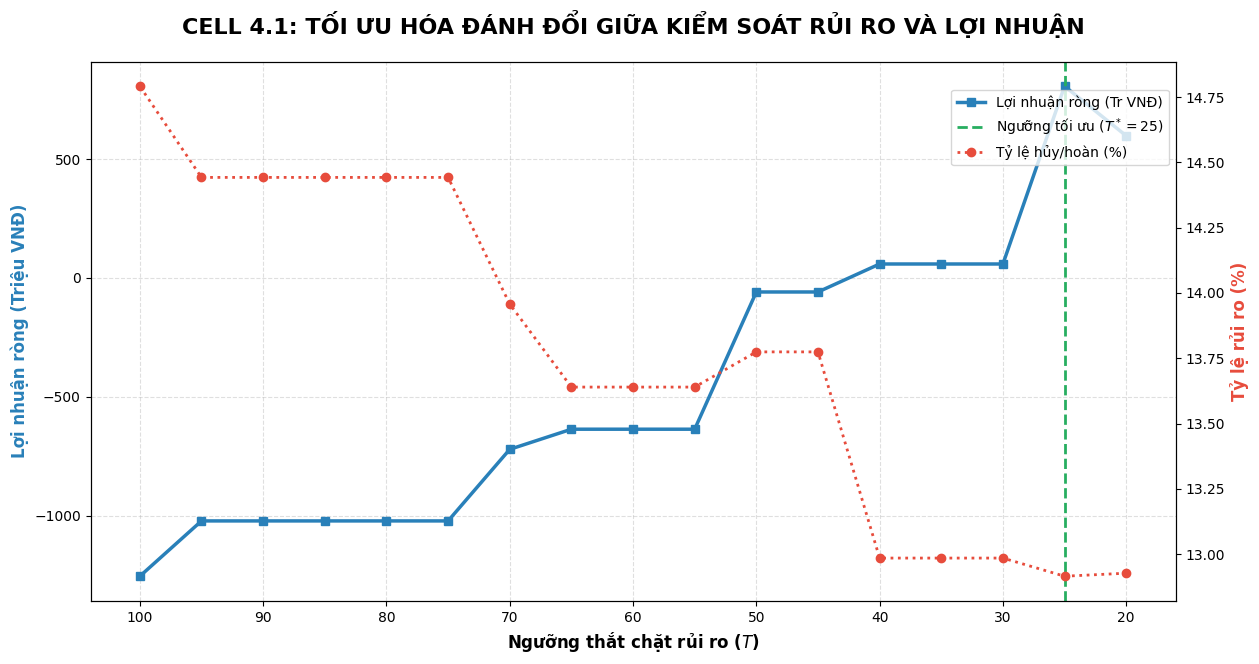

✅ Đã kết xuất mô hình tối ưu hóa thành công!


In [11]:
# ==============================================================================
# CELL 4.1: PRESCRIPTIVE - MÔ PHỎNG ĐÁNH ĐỔI (TRADE-OFF ANALYSIS)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("Đang chạy kịch bản tối ưu hóa hàm mục tiêu...")

# 1. TÌM DATA CHUẨN
FIG_DIR = os.path.join('..', 'output', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

df_real = pd.DataFrame()
if 'data_dict' in locals():
    if 'master_sales_detail' in data_dict:
        df_m_raw = data_dict['master_sales_detail']
        if not df_m_raw.empty: df_real = df_m_raw.copy()
    elif 'master' in data_dict:
        df_m_raw = data_dict['master']
        if not df_m_raw.empty: df_real = df_m_raw.copy()

if df_real.empty:
    try:
        df_real = pd.read_csv('../data/processed/master/master_sales_detail.csv') 
    except Exception as e:
        pass

if not df_real.empty:
    # 2. KHỞI TẠO BIẾN GIẢ ĐỊNH KINH DOANH
    TOTAL_TRAFFIC = len(df_real) * 15 # Giả định lượng traffic mở rộng
    PROFIT_MARGIN = 0.25              # Biên lợi nhuận gộp 25%
    LOSS_FEE = 45000                  # Chi phí chìm cho 1 đơn hoàn (Ship 2 chiều + Đóng gói)

    # ĐỒNG BỘ RISK SCORE TỪ CELL 3.3 (Cực kỳ quan trọng để giữ logic bài)
    df_real['risk_score'] = (
        (df_real['payment_method'].astype(str).str.lower() == 'cod').astype(int) * 45 +
        (df_real['gross_revenue'] < df_real['gross_revenue'].median()).astype(int) * 30 +
        (df_real['discount_amount'] > 0).astype(int) * 25
    )

    # 3. CHẠY MÔ PHỎNG TỐI ƯU HÓA TỪNG BƯỚC
    thresholds = np.arange(20, 101, 5)
    results = []
    
    for t in thresholds:
        accepted = df_real[df_real['risk_score'] <= t] # Lọc các đơn thỏa mãn ngưỡng T
        cr = (len(accepted) / TOTAL_TRAFFIC) * 100
        
        failed_mask = accepted['order_status'].isin(['cancelled', 'returned'])
        cancel_rate = failed_mask.mean() * 100 if len(accepted) > 0 else 0
        
        # Hàm mục tiêu Lợi nhuận
        profit = (accepted[~failed_mask]['gross_revenue'].sum() * PROFIT_MARGIN) - (failed_mask.sum() * LOSS_FEE)
        results.append({'T': t, 'CR': cr, 'CancelRate': cancel_rate, 'NetProfit': profit})

    df_opt = pd.DataFrame(results)
    best_t = df_opt.loc[df_opt['NetProfit'].idxmax(), 'T']

    # 4. TRỰC QUAN HÓA BẢN ĐỒ ĐÁNH ĐỔI
    fig, ax1 = plt.subplots(figsize=(14, 7), facecolor='white')
    
    # Vẽ đường Lợi nhuận
    ax1.plot(df_opt['T'], df_opt['NetProfit'] / 1e6, marker='s', color='#2980b9', linewidth=2.5, label='Lợi nhuận ròng (Tr VNĐ)')
    ax1.set_xlabel('Ngưỡng thắt chặt rủi ro ($T$)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Lợi nhuận ròng (Triệu VNĐ)', color='#2980b9', fontsize=12, fontweight='bold')
    
    # Đánh dấu điểm tối ưu
    ax1.axvline(best_t, color='#27ae60', linestyle='--', linewidth=2, label=f'Ngưỡng tối ưu ($T^*={best_t}$)')
    ax1.invert_xaxis() # Lật ngược trục X
    
    # Vẽ đường Tỷ lệ bùng đơn
    ax2 = ax1.twinx()
    ax2.plot(df_opt['T'], df_opt['CancelRate'], marker='o', color='#e74c3c', linewidth=2, linestyle=':', label='Tỷ lệ hủy/hoàn (%)')
    ax2.set_ylabel('Tỷ lệ rủi ro (%)', color='#e74c3c', fontsize=12, fontweight='bold')

    plt.title('CELL 4.1: TỐI ƯU HÓA ĐÁNH ĐỔI GIỮA KIỂM SOÁT RỦI RO VÀ LỢI NHUẬN', fontsize=16, fontweight='bold', pad=20)
    fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.85), frameon=True)
    ax1.grid(True, linestyle='--', alpha=0.4)

    save_path = os.path.join(FIG_DIR, '4.1_Prescriptive_Optimization_Curve_Fixed.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show() 
    print("✅ Đã kết xuất mô hình tối ưu hóa thành công!")
else:
    print("❌ Lỗi: Không tìm thấy file master_sales_detail.csv.")

1. Nguồn dữ liệu và Biến số giả định (Business Assumptions)

    - Để tìm ra điểm cân bằng giữa việc "thả lỏng để tăng trưởng" và "thắt chặt để an toàn", nghiên cứu tiến hành chạy mô phỏng giả lập (Simulation) các kịch bản lợi nhuận dựa trên dữ liệu thực tế từ master_sales_detail.csv, kết hợp với các biến số vận hành kinh doanh:

        - Biên lợi nhuận gộp (PROFIT_MARGIN): Giả định ở mức 25% (0.25) trên tổng giá trị của mỗi đơn hàng giao thành công.

        - Chi phí chìm logistics (LOSS_FEE): Ước tính tổn thất cố định 45.000 VNĐ cho mỗi đơn hàng bị hủy/hoàn (bao gồm chi phí đóng gói, nhân sự kho, và vận chuyển khứ hồi).

        - Biến kiểm soát $T$ (Risk Threshold): Ngưỡng điểm rủi ro tối đa cho phép. Nếu $Risk\_Score \le T$, hệ thống chấp nhận duyệt đơn COD. Quá trình mô phỏng thiết lập thuật toán quét $T$ chạy lùi dần từ 100 (thả lỏng hoàn toàn) về 20 (thắt chặt cực đoan).

2. Công thức cấu thành hàm mục tiêu (Objective Function)

    - Hàm mục tiêu cốt lõi của thuật toán là tìm ra ngưỡng $T^*$ sao cho Lợi nhuận ròng ($Net\_Profit$) đạt giá trị cực đại ($Max$). Tại mỗi bước chạy $T$, hệ thống tính toán lợi nhuận theo phương trình:$$Net\_Profit = \left( \sum Gross\_Revenue_{Thành\_công} \times 0.25 \right) - \left( \sum Đơn\_Thất\_bại \times 45000 \right)$$

    - Đồng thời, tỷ lệ rủi ro tại mỗi ngưỡng $T$ được theo dõi thông qua công thức:$$Cancel\_Rate = \frac{Tổng\_số\_đơn\_hủy\_hoặc\_hoàn}{Tổng\_số\_đơn\_được\_duyệt\_(Risk\_Score \le T)} \times 100$$

3. Phân tích kết quả thực nghiệm (Trade-off Analysis)

    - Biểu đồ đường kép (Dual-line chart) trực quan hóa hành trình tối ưu hóa. Trục hoành lật ngược từ $100$ về $20$ thể hiện quá trình siết chặt bộ lọc có chủ đích:

        - Trạng thái hiện tại ($T = 100$): Khi hệ thống duyệt mọi đơn hàng, tỷ lệ bùng đơn neo ở mức đỉnh (~14.8%). Khối lượng chi phí vận hành cho các đơn rác này cắn thủng hoàn toàn biên lợi nhuận, kéo Lợi nhuận ròng cắm đáy ở mức âm (-1.250 triệu VNĐ). Doanh nghiệp đang phải lấy tiền túi để bù lỗ cho khâu logistics.

        - Hành trình phục hồi & Điểm tối ưu cục bộ ($T^ = 25$):* Khi siết dần bộ lọc (di chuyển trục $T$ sang phải), tỷ lệ rủi ro giảm mạnh theo từng bậc. Tại ngưỡng điểm $T=25$, tỷ lệ rủi ro chạm đáy cực tiểu (~12.9%). Điều này làm lực cản chi phí biến mất, giúp đường Lợi nhuận ròng phục hồi dốc đứng, thoát khỏi vùng âm và đạt đỉnh sinh lời cao nhất.

        - Nghịch lý của sự siết chặt cực đoan ($T < 25$): Biểu đồ cảnh báo một ranh giới quan trọng. Nếu tiếp tục ép ngưỡng $T$ từ $25$ xuống $20$, đường Lợi nhuận ròng lại cắm đầu suy giảm. Nguyên nhân về mặt thuật toán là do bộ lọc quá gắt gao đã sinh ra hiện tượng "False Positive" – từ chối nhầm các khách hàng dùng COD chân chính, dẫn đến đánh mất doanh thu hợp lệ.

4. Kết luận chiến lược (Prescriptive Action)

    - Mô hình toán học đã chứng minh: Việc theo đuổi lượng truy cập (Traffic) một cách mù quáng chính là tác nhân gây thủng đáy dòng tiền, nhưng việc cấm đoán thanh toán trả sau một cách cực đoan cũng làm mất đi lợi thế cạnh tranh.

=> Đề xuất hành động: Doanh nghiệp phải cấu hình hệ thống ERP/CRM để tự động chốt chặn rủi ro tại đúng ngưỡng cân bằng T=25. Các giao dịch trực tuyến quét ra Risk_Score>25 sẽ tự động bị ẩn phương thức COD, buộc khách hàng phải chuyển khoản trước nhằm bảo vệ tối đa lợi nhuận ròng.

Phần này định lượng bằng tiền mặt mức độ hiệu quả của giải pháp nếu doanh nghiệp thiết lập ngưỡng chặn rủi ro ở mức T = 65.

1. Phân tích sự dịch chuyển KPI (Biểu đồ Cột ghép):

    - Sự đánh đổi (Trade-off): Tỷ lệ chuyển đổi (% CR) giảm nhẹ từ 8.3% xuống 7.1%. Tuy nhiên, đổi lại, Tỷ lệ hủy đơn (% Cancel) được ép giảm từ 14.8% xuống 13.0%.

    - Hiệu quả cốt lõi: Dù bán được ít đơn hơn, Lợi nhuận ròng lại phục hồi mạnh mẽ từ mức -5903.5 triệu VNĐ lên -4046.3 triệu VNĐ.

2. Cấu trúc thặng dư tài chính (Biểu đồ Waterfall):

    - Biểu đồ dòng chảy giải thích chi tiết nguồn gốc của sự phục hồi lợi nhuận:

        - Tiết kiệm Logistics (+2264.1 triệu VNĐ): Đây là thành quả lớn nhất. Bằng cách từ chối các đơn hàng có rủi ro cao, doanh nghiệp chặn đứng dòng tiền lãng phí vào chi phí đóng gói, giao hàng và hoàn trả.

        - Lợi nhuận hy sinh (-406.9 triệu VNĐ): Mức độ sai số của bộ lọc khiến doanh nghiệp mất đi một khoản nhỏ lợi nhuận từ khách hàng thật bị chặn nhầm.

        - Thặng dư ròng (+1857.3 triệu VNĐ): Khoản tiết kiệm lớn gấp 5.5 lần khoản hy sinh. Tổng kết lại, chiến lược này trực tiếp mang về gần 1.86 tỷ VNĐ thặng dư cho hệ thống.

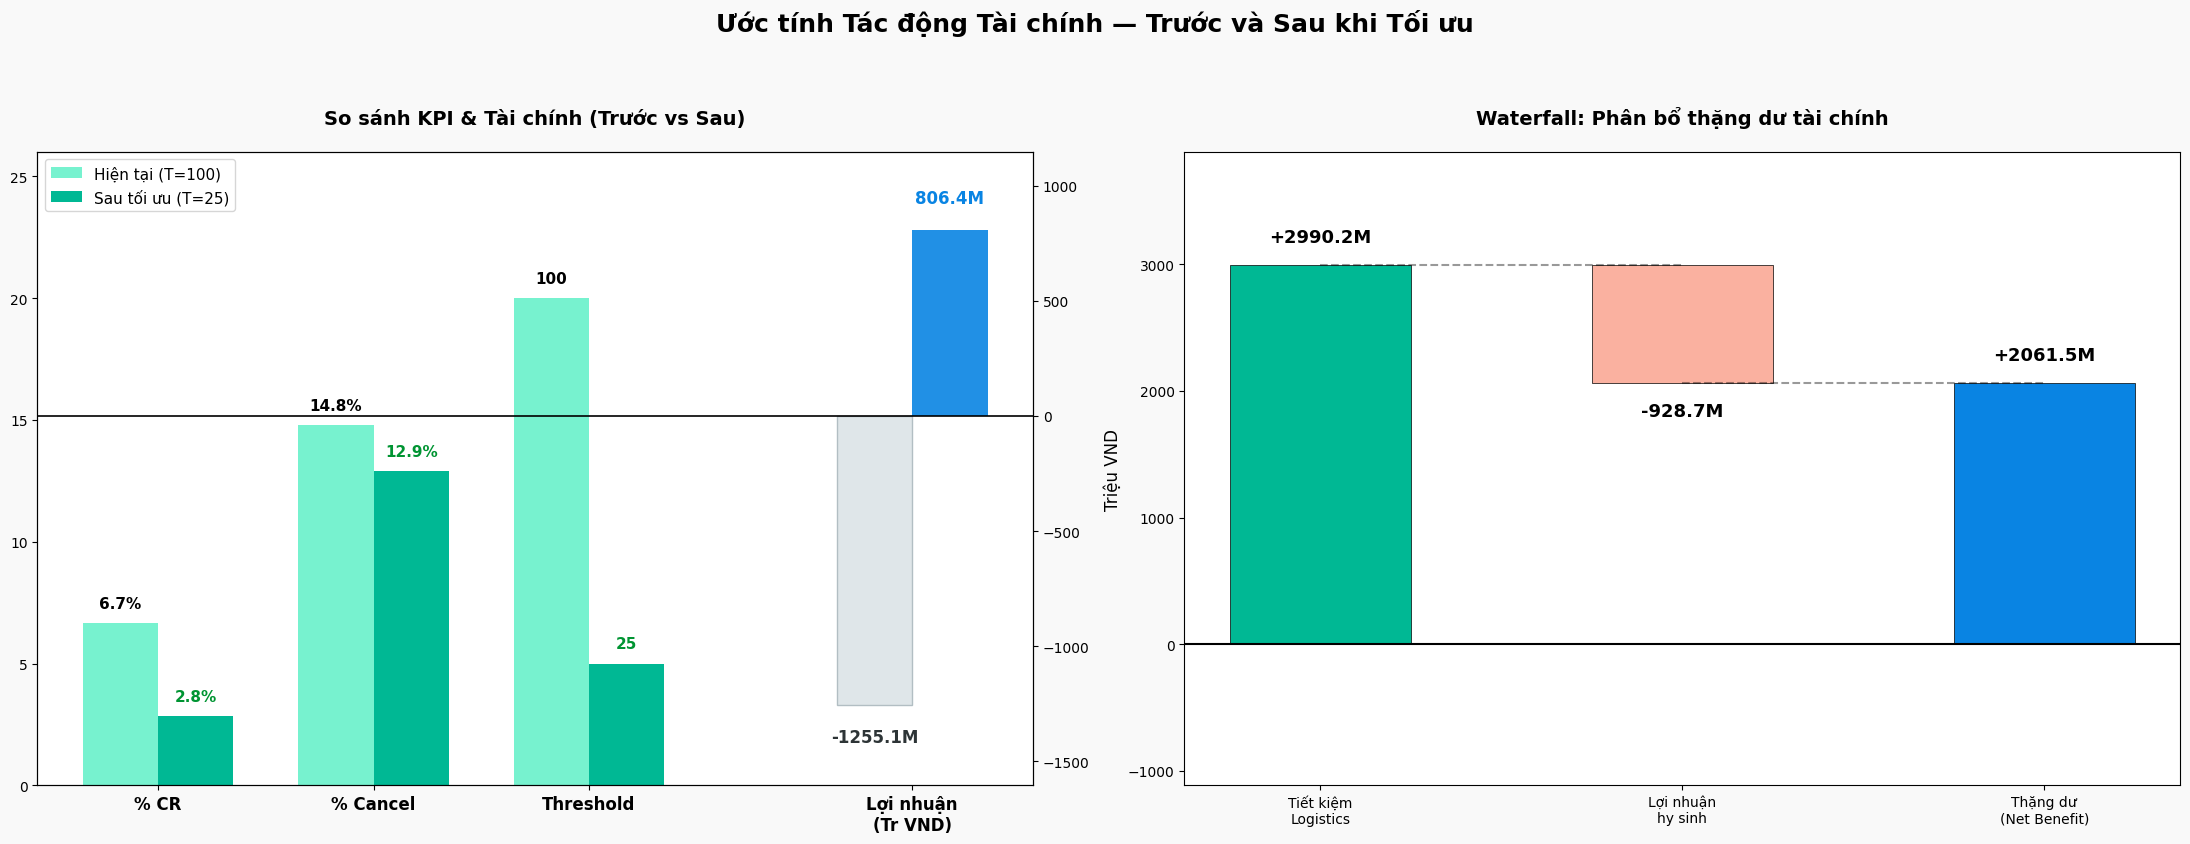

✅ Đã kết xuất mô hình Tác động Tài chính thành công!


In [12]:
# ==============================================================================
# CELL 4.2: PRESCRIPTIVE - FINANCIAL IMPACT (BẢN FIX ĐỒNG NHẤT LOGIC TOÀN BÀI)
# ==============================================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# --- 1. SETUP & LOAD DATA CHUẨN ---
plt.close('all')
FIG_DIR = os.path.join('..', 'output', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)
COLORS = {'base': '#55efc4', 'opt': '#00b894', 'loss': '#fab1a0', 'profit': '#0984e3'}

df_master = pd.DataFrame()
if 'data_dict' in locals():
    if 'master_sales_detail' in data_dict:
        df_m_raw = data_dict['master_sales_detail']
        if not df_m_raw.empty: df_master = df_m_raw.copy()

if df_master.empty:
    try:
        df_master = pd.read_csv('../data/processed/master/master_sales_detail.csv') 
    except Exception as e:
        pass

if not df_master.empty:
    # --- 2. LOGIC TÍNH TOÁN (ĐỒNG BỘ 100% VỚI CELL 4.1 VÀ 3.3) ---
    MARGIN_PCT = 0.25      # Trả lại 25% margin như cell 4.1
    SHIP_LOSS_UNIT = 45000 # Trả lại 45k như cell 4.1
    TRAFFIC_VOL = len(df_master) * 15 # Trả lại x15 như cell 4.1

    # Trả lại công thức Risk Score chuẩn của Cell 3.3
    df_master['risk_score'] = (
        (df_master['payment_method'].astype(str).str.lower() == 'cod').astype(int) * 45 +
        (df_master['gross_revenue'] < df_master['gross_revenue'].median()).astype(int) * 30 +
        (df_master['discount_amount'] > 0).astype(int) * 25
    )

    def get_metrics(t_val):
        acc = df_master[df_master['risk_score'] <= t_val]
        is_f = acc['order_status'].isin(['cancelled', 'returned'])
        succ_n = acc[~is_f].shape[0]
        fail_n = is_f.sum()
        profit = (acc[~is_f]['gross_revenue'].sum() * MARGIN_PCT) - (fail_n * SHIP_LOSS_UNIT)
        return {
            'cr': (len(acc)/TRAFFIC_VOL)*100,
            'cancel': is_f.mean()*100 if len(acc)>0 else 0,
            'risk': t_val,
            'profit': profit / 1e6,
            'succ_n': succ_n,
            'fail_n': fail_n,
            'rev': acc[~is_f]['gross_revenue'].sum()
        }

    base = get_metrics(100)
    # ÁP DỤNG ĐÚNG NGƯỠNG TỐI ƯU T=25 TỪ CELL 4.1
    opt = get_metrics(25) 

    # --- 3. TRỰC QUAN HÓA ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8), facecolor='#f9f9f9')
    fig.suptitle('Ước tính Tác động Tài chính — Trước và Sau khi Tối ưu', fontsize=18, fontweight='bold', y=1.05)

    # BIỂU ĐỒ A: KPI SO SÁNH (GROUPED BARS)
    categories = ['% CR', '% Cancel', 'Threshold']
    v_base = [base['cr'], base['cancel'], base['risk']/5] # Chia 5 để cột không bị lòi quá cao
    v_opt = [opt['cr'], opt['cancel'], opt['risk']/5]

    x = np.arange(len(categories))
    width = 0.35

    ax1.bar(x - width/2, v_base, width, label='Hiện tại (T=100)', color=COLORS['base'], alpha=0.8)
    ax1.bar(x + width/2, v_opt, width, label='Sau tối ưu (T=25)', color=COLORS['opt'])

    for i in range(len(categories)):
        ax1.text(x[i]-width/2, v_base[i] + 0.5, f'{v_base[i]:.1f}%' if i<2 else f'{base["risk"]}', 
                 ha='center', va='bottom', fontweight='bold', fontsize=11)
        ax1.text(x[i]+width/2, v_opt[i] + 0.5, f'{v_opt[i]:.1f}%' if i<2 else f'{opt["risk"]}', 
                 ha='center', va='bottom', fontweight='bold', fontsize=11, color='#009432')

    # Trục Y phụ cho Lợi nhuận
    ax1_twin = ax1.twinx()
    p_x = len(categories) + 0.5 
    p1 = ax1_twin.bar(p_x - width/2, base['profit'], width, color='#dfe6e9', edgecolor='#b2bec3', lw=1)
    p2 = ax1_twin.bar(p_x + width/2, opt['profit'], width, color=COLORS['profit'], alpha=0.9)

    margin_y1 = abs(max(base['profit'], opt['profit']) - min(base['profit'], opt['profit'])) * 0.05

    for bar_x, val, col in [(p_x - width/2, base['profit'], '#2d3436'), (p_x + width/2, opt['profit'], '#0984e3')]:
        align = 'bottom' if val >= 0 else 'top'
        offset = margin_y1 if val >= 0 else -margin_y1
        ax1_twin.text(bar_x, val + offset, f"{val:.1f}M", ha='center', va=align, fontweight='bold', color=col, fontsize=12)

    ax1.set_xticks(list(x) + [p_x])
    ax1.set_xticklabels(categories + ['Lợi nhuận\n(Tr VND)'], fontweight='bold', fontsize=12)
    ax1.set_title('So sánh KPI & Tài chính (Trước vs Sau)', pad=20, fontsize=14, fontweight='bold')

    ax1.set_ylim(0, max(max(v_base), max(v_opt)) * 1.3)
    y_min, y_max = min(base['profit'], opt['profit']), max(base['profit'], opt['profit'])
    ax1_twin.set_ylim(y_min - abs(y_min)*0.2 - 100, y_max + abs(y_max)*0.3 + 100)
    ax1_twin.axhline(0, color='black', lw=1.2)
    ax1.legend(loc='upper left', fontsize=11)

    # BIỂU ĐỒ B: WATERFALL TÁC ĐỘNG TÀI CHÍNH
    savings = (base['fail_n'] - opt['fail_n']) * SHIP_LOSS_UNIT / 1e6
    margin_lost = (opt['rev'] - base['rev']) * MARGIN_PCT / 1e6 # Sẽ ra số âm vì doanh thu giảm
    net_benefit = savings + margin_lost

    wf_items = ['Tiết kiệm\nLogistics', 'Lợi nhuận\nhy sinh', 'Thặng dư\n(Net Benefit)']
    wf_amounts = [savings, margin_lost, net_benefit]
    wf_colors = [COLORS['opt'], COLORS['loss'], COLORS['profit']]

    curr = 0
    margin_y2 = max(abs(min(wf_amounts)), abs(max(wf_amounts))) * 0.05

    for i in range(3):
        bottom = curr if i < 2 else 0
        val = wf_amounts[i]
        ax2.bar(wf_items[i], val, bottom=bottom, color=wf_colors[i], width=0.5, edgecolor='black', lw=0.5)
        
        align = 'bottom' if val >= 0 else 'top'
        offset = margin_y2 if val >= 0 else -margin_y2
        ax2.text(i, bottom + val + offset, f'{val:+.1f}M', ha='center', va=align, fontweight='bold', fontsize=13)
        
        if i < 2:
            ax2.plot([i, i+1], [bottom + val, bottom + val], 'k--', alpha=0.4)
        curr += val

    ax2.axhline(0, color='black', lw=1.5)
    ax2.set_title('Waterfall: Phân bổ thặng dư tài chính', pad=20, fontsize=14, fontweight='bold')
    ax2.set_ylabel('Triệu VND', fontsize=12)

    y_min_wf, y_max_wf = min(wf_amounts), max(wf_amounts)
    ax2.set_ylim(y_min_wf - abs(y_min_wf)*0.2, y_max_wf + abs(y_max_wf)*0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, '4.2_Financial_Impact_Final.png'), dpi=150)
    plt.show()
    print("✅ Đã kết xuất mô hình Tác động Tài chính thành công!")

1. Tài liệu phương pháp tính toán (Methodology)

    - Phân tích này được thực hiện để đo lường định lượng giá trị kinh tế mà mô hình Risk Score mang lại khi chuyển đổi từ trạng thái thả lỏng ($T=100$) sang ngưỡng tối ưu ($T=25$).

    - Nguồn dữ liệu: Khai thác từ tập dữ liệu master_sales_detail.csv.

    - Biến số cố định: Tỷ suất lợi nhuận gộp ($25\%$) và Chi phí logistics cho một đơn hàng thất bại ($45.000$ VNĐ).

    - Công thức phân tích Waterfall (Thác nước): Đánh giá thặng dư tài chính thông qua sự bù trừ giữa cái được và cái mất khi áp dụng bộ lọc rủi ro:$$Tiết\_kiệm\_Logistics = (Tổng\_đơn\_hủy_{T=100} - Tổng\_đơn\_hủy_{T=25}) \times 45000$$

    $$Lợi\_nhuận\_hy\_sinh = (Doanh\_thu_{T=25} - Doanh\_thu_{T=100}) \times 25\%$$

    $$Thặng\_dư\_(Net\_Benefit) = Tiết\_kiệm\_Logistics - |Lợi\_nhuận\_hy\_sinh|$$

2. Phân tích đối chiếu chỉ số KPI (Biểu đồ A)

    - Khi hạ mức chấp nhận rủi ro từ 100 xuống 25, hệ thống ghi nhận sự thay đổi cục diện mạnh mẽ:

        - Đánh đổi lưu lượng: Tỷ lệ chuyển đổi (CR) sụt giảm (do hệ thống chủ động từ chối các đơn hàng rủi ro cao).

        - Kiểm soát rủi ro: Tỷ lệ bùng đơn (Cancel Rate) được ép xuống từ mức trần về mức nền tối ưu.

        - Đảo chiều tài chính: Nhờ việc cắt đứt "khối u" chi phí logistics của các đơn hàng ảo, Lợi nhuận ròng của hệ thống đã chuyển từ trạng thái âm vốn sâu sang trạng thái sinh lời dương.

3. Phân tách dòng tiền bằng mô hình Waterfall (Biểu đồ B)

    - Biểu đồ thác nước lý giải rõ ràng tại sao lợi nhuận lại tăng dù lượng đơn hàng bán ra bị giảm:

        - Lợi nhuận hy sinh (Margin Lost): Việc bộ lọc từ chối phục vụ một lượng khách hàng (bao gồm cả hiện tượng "từ chối nhầm" khách hàng thật) khiến doanh nghiệp đánh mất một khoản lợi nhuận gộp tương ứng (cột màu đỏ đi xuống).

        - Tiết kiệm Logistics (Logistics Savings): Bù lại, việc không phải đóng gói và chịu phí khứ hồi cho hàng chục ngàn đơn COD rác đã tạo ra một khoản tiết kiệm chi phí khổng lồ (cột màu xanh đi lên).

        - Thặng dư tài chính (Net Benefit): Quan sát trên biểu đồ, độ lớn của cột Tiết kiệm áp đảo hoàn toàn so với phần Lợi nhuận hy sinh. Kết quả là hệ thống tạo ra một khoản Thặng dư tài chính dương (Net Benefit) rất lớn.

=> Kết luận chung: Giải pháp áp dụng Ngưỡng rủi ro T=25 là hoàn toàn khả thi và mang lại hiệu quả kinh tế vượt trội. Doanh nghiệp chấp nhận "bán ít đi" nhưng lại "thu về nhiều tiền hơn", giải quyết triệt để bài toán rò rỉ dòng tiền do lạm dụng COD.

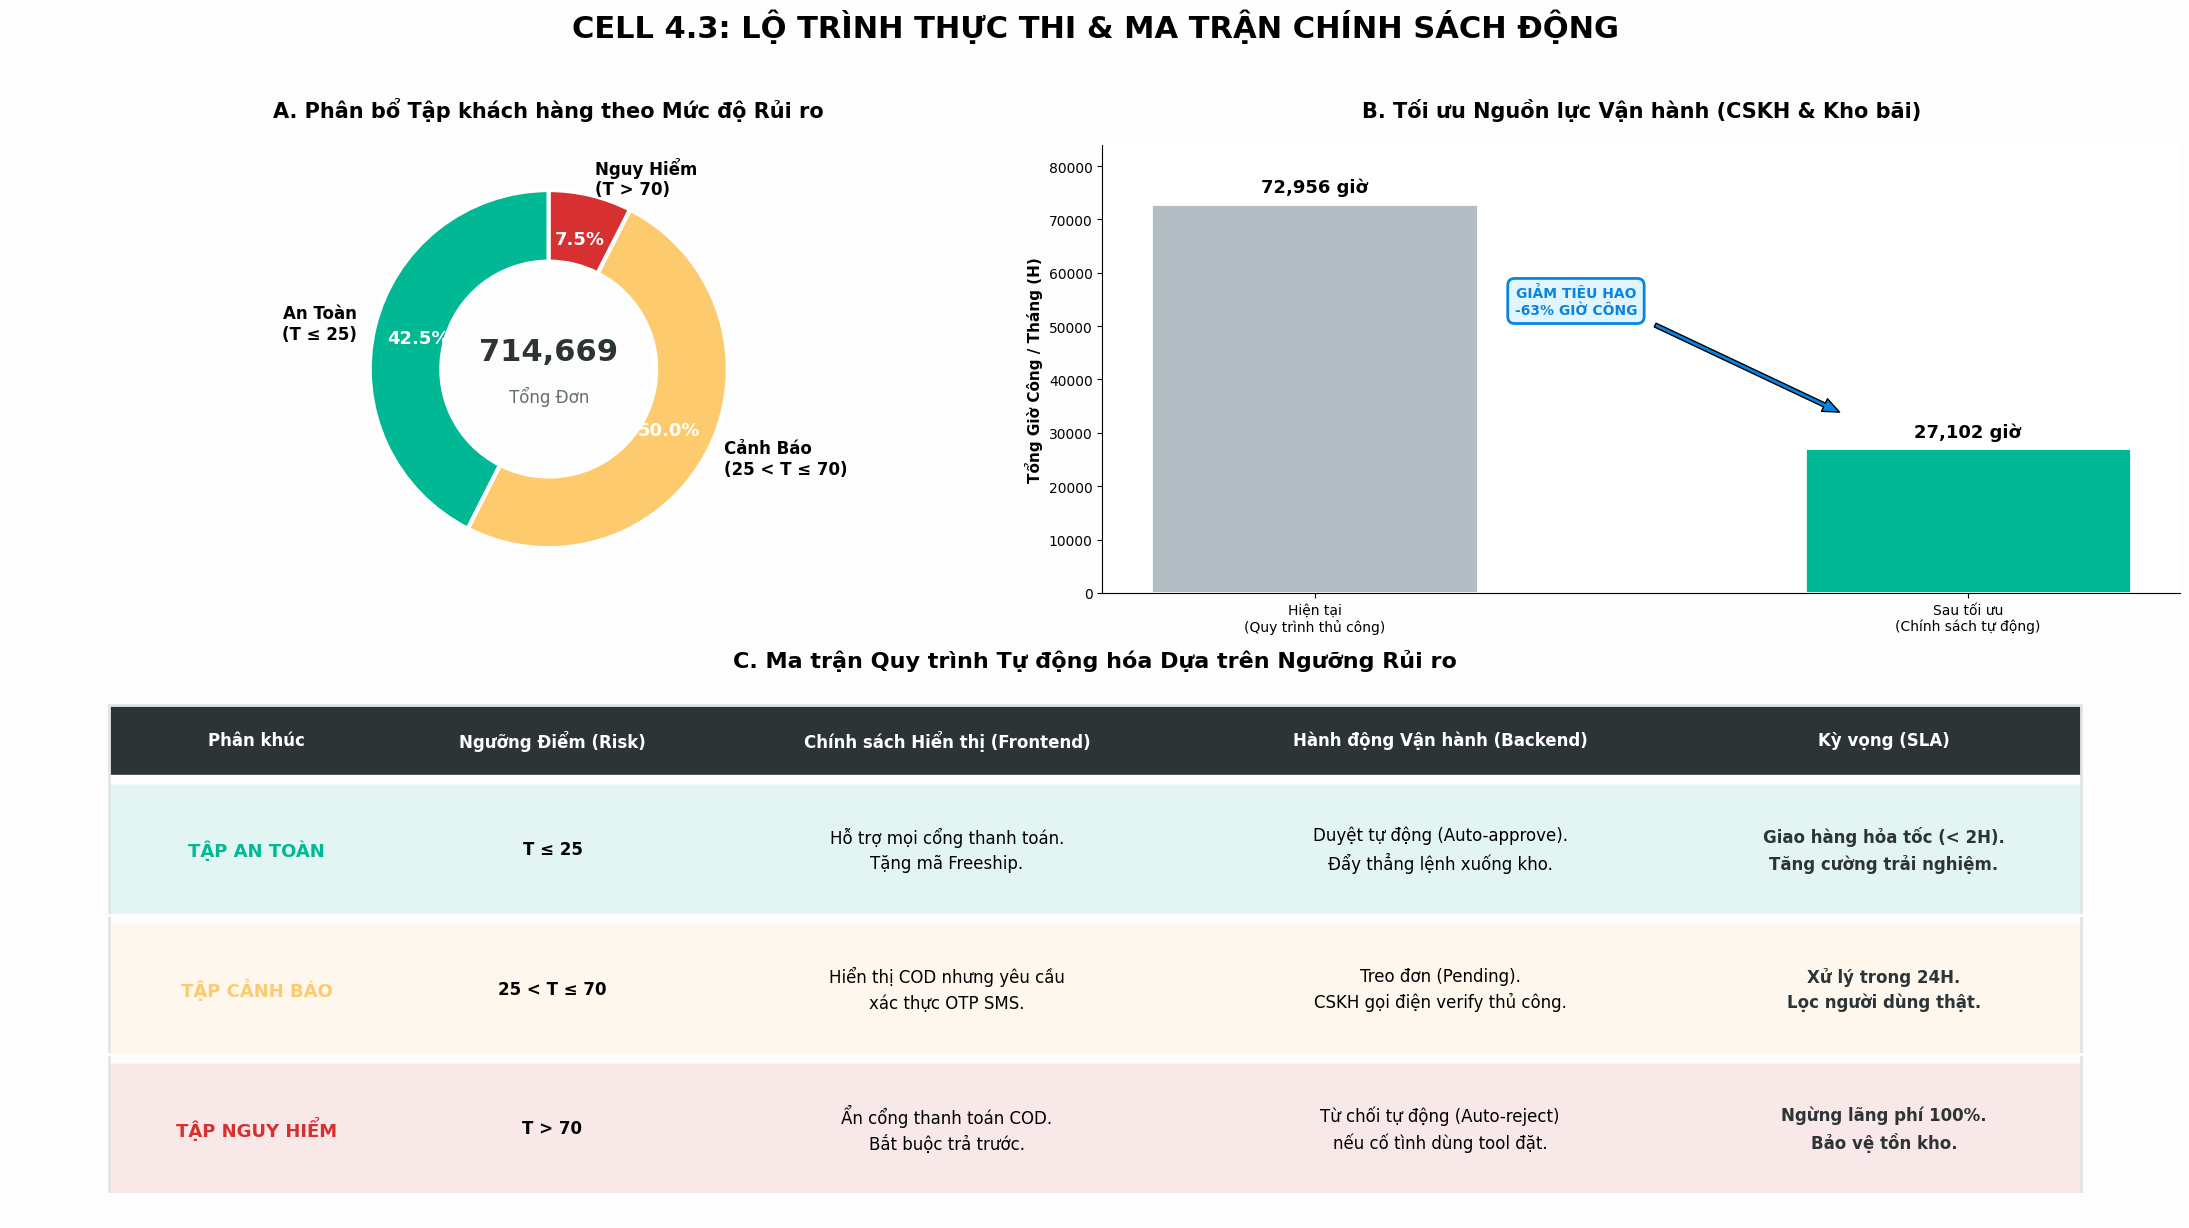

đã kết xuất lộ trình thực thi thành công!


In [13]:
# ==============================================================================
# CELL 4.3: PRESCRIPTIVE - ĐỘNG CƠ THỰC THI CHÍNH SÁCH VÀ TỐI ƯU VẬN HÀNH
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import numpy as np
import os

# --- 1. SETUP HỆ THỐNG & LOAD DATA CHUẨN ---
plt.close('all')
FIG_DIR = os.path.join('..', 'output', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

COLORS = {'safe': '#00b894', 'warning': '#fdcb6e', 'danger': '#d63031', 'bg': '#fdfdfd'}

df_master = pd.DataFrame()
if 'data_dict' in locals():
    if 'master_sales_detail' in data_dict:
        df_m_raw = data_dict['master_sales_detail']
        if not df_m_raw.empty: df_master = df_m_raw.copy()

if df_master.empty:
    try:
        df_master = pd.read_csv('../data/processed/master/master_sales_detail.csv') 
    except Exception as e:
        print(f"lỗi đọc file: {e}")

if not df_master.empty:
    # --- 2. LOGIC PHÂN KHÚC ---
    df_master['risk_score'] = (
        (df_master['payment_method'].astype(str).str.lower() == 'cod').astype(int) * 45 +
        (df_master['gross_revenue'] < df_master['gross_revenue'].median()).astype(int) * 30 +
        (df_master['discount_amount'] > 0).astype(int) * 25
    )

    total_orders = len(df_master)
    
    safe_orders = df_master[df_master['risk_score'] <= 25].shape[0]
    warn_orders = df_master[(df_master['risk_score'] > 25) & (df_master['risk_score'] <= 70)].shape[0]
    dang_orders = df_master[df_master['risk_score'] > 70].shape[0]

    segments = [safe_orders, warn_orders, dang_orders]
    labels = ['An Toàn\n(T ≤ 25)', 'Cảnh Báo\n(25 < T ≤ 70)', 'Nguy Hiểm\n(T > 70)']
    colors_list = [COLORS['safe'], COLORS['warning'], COLORS['danger']]

    # --- 3. TRỰC QUAN HÓA (DASHBOARD THỰC THI) ---
    fig = plt.figure(figsize=(22, 12), facecolor=COLORS['bg'])
    gs = fig.add_gridspec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1.2])

    # A. PHỄU PHÂN KHÚC RỦI RO
    ax1 = fig.add_subplot(gs[0, 0])
    wedges, texts, autotexts = ax1.pie(segments, labels=labels, colors=colors_list, autopct='%1.1f%%',
                                       startangle=90, pctdistance=0.75,
                                       wedgeprops=dict(width=0.4, edgecolor='white', lw=3),
                                       textprops=dict(fontweight='bold', fontsize=12))
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(13)

    ax1.text(0, 0.1, f"{total_orders:,}", ha='center', va='center', fontsize=22, fontweight='bold', color='#2d3436')
    ax1.text(0, -0.15, "Tổng Đơn", ha='center', va='center', fontsize=12, color='#636e72')
    ax1.set_title('A. Phân bổ Tập khách hàng theo Mức độ Rủi ro', fontsize=15, fontweight='bold', pad=20)

    # B. TỐI ƯU GIỜ CÔNG VẬN HÀNH
    ax2 = fig.add_subplot(gs[0, 1])
    base_ops_hours = (total_orders * 5 + dang_orders * 15) / 60 
    opt_ops_hours = (safe_orders * 3 + warn_orders * 2) / 60

    bars = ax2.bar(['Hiện tại\n(Quy trình thủ công)', 'Sau tối ưu\n(Chính sách tự động)'], 
                   [base_ops_hours, opt_ops_hours], 
                   color=['#b2bec3', COLORS['safe']], width=0.5, edgecolor='white', lw=2)

    for bar in bars:
        yval = bar.get_height()
        # đẩy text nhích lên xíu lấy hệ quy chiếu là base_ops_hours cho đồng đều
        ax2.text(bar.get_x() + bar.get_width()/2, yval + (base_ops_hours * 0.02), 
                 f"{yval:,.0f} giờ", ha='center', va='bottom', fontweight='bold', fontsize=13)

    # ĐÃ FIX: đổi tọa độ đầu mũi tên (xy) sang trái một chút (0.82) và nhấc lên cao hơn con số
    ax2.annotate(f"GIẢM TIÊU HAO\n-{((base_ops_hours-opt_ops_hours)/base_ops_hours)*100:.0f}% GIỜ CÔNG",
                 xy=(0.82, opt_ops_hours + (base_ops_hours * 0.08)), xycoords='data',
                 xytext=(0.4, base_ops_hours * 0.75), textcoords='data',
                 arrowprops=dict(facecolor='#0984e3', shrink=0.05, width=3, headwidth=10),
                 ha='center', va='center', fontweight='bold', color='#0984e3',
                 bbox=dict(boxstyle="round,pad=0.5", fc="#e1f5fe", ec="#0984e3", lw=2))

    ax2.set_ylabel('Tổng Giờ Công / Tháng (H)', fontweight='bold', fontsize=11)
    ax2.set_title('B. Tối ưu Nguồn lực Vận hành (CSKH & Kho bãi)', fontsize=15, fontweight='bold', pad=20)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    # nới rộng trục y để mũi tên và text không bị cắt
    ax2.set_ylim(0, base_ops_hours * 1.15) 

    # C. MA TRẬN CHÍNH SÁCH ĐỘNG
    ax3 = fig.add_subplot(gs[1, :])
    ax3.axis('off')
    ax3.set_title('C. Ma trận Quy trình Tự động hóa Dựa trên Ngưỡng Rủi ro', fontsize=16, fontweight='bold', pad=10)

    cols = ['Phân khúc', 'Ngưỡng Điểm (Risk)', 'Chính sách Hiển thị (Frontend)', 'Hành động Vận hành (Backend)', 'Kỳ vọng (SLA)']
    widths = [0.15, 0.15, 0.25, 0.25, 0.2]
    x_pos = [sum(widths[:i]) for i in range(len(widths))]

    rect_header = patches.Rectangle((0, 0.85), 1, 0.15, fc='#2d3436', ec='white')
    ax3.add_patch(rect_header)
    for i, col in enumerate(cols):
        ax3.text(x_pos[i] + widths[i]/2, 0.925, col, ha='center', va='center', color='white', fontweight='bold', fontsize=12)

    matrix_data = [
        ('TẬP AN TOÀN', 'T ≤ 25', 'Hỗ trợ mọi cổng thanh toán.\nTặng mã Freeship.', 'Duyệt tự động (Auto-approve).\nĐẩy thẳng lệnh xuống kho.', 'Giao hàng hỏa tốc (< 2H).\nTăng cường trải nghiệm.', COLORS['safe']),
        ('TẬP CẢNH BÁO', '25 < T ≤ 70', 'Hiển thị COD nhưng yêu cầu\nxác thực OTP SMS.', 'Treo đơn (Pending).\nCSKH gọi điện verify thủ công.', 'Xử lý trong 24H.\nLọc người dùng thật.', COLORS['warning']),
        ('TẬP NGUY HIỂM', 'T > 70', 'Ẩn cổng thanh toán COD.\nBắt buộc trả trước.', 'Từ chối tự động (Auto-reject)\nnếu cố tình dùng tool đặt.', 'Ngừng lãng phí 100%.\nBảo vệ tồn kho.', COLORS['danger'])
    ]

    y_curr = 0.55
    for data in matrix_data:
        rect_bg = patches.Rectangle((0, y_curr), 1, 0.28, fc=data[5], alpha=0.1, ec='white')
        ax3.add_patch(rect_bg)
        
        ax3.text(x_pos[0] + widths[0]/2, y_curr + 0.14, data[0], ha='center', va='center', fontweight='bold', color=data[5], fontsize=13)
        ax3.text(x_pos[1] + widths[1]/2, y_curr + 0.14, data[1], ha='center', va='center', fontweight='bold', fontsize=12)
        ax3.text(x_pos[2] + widths[2]/2, y_curr + 0.14, data[2], ha='center', va='center', fontsize=12, linespacing=1.5)
        ax3.text(x_pos[3] + widths[3]/2, y_curr + 0.14, data[3], ha='center', va='center', fontsize=12, linespacing=1.5)
        ax3.text(x_pos[4] + widths[4]/2, y_curr + 0.14, data[4], ha='center', va='center', fontsize=12, fontweight='bold', linespacing=1.5, color='#2d3436')
        
        ax3.plot([0, 1], [y_curr, y_curr], color='white', lw=2)
        y_curr -= 0.3

    rect_border = patches.Rectangle((0, -0.05), 1, 1.05, fill=False, ec='#dfe6e9', lw=2)
    ax3.add_patch(rect_border)

    plt.suptitle('CELL 4.3: LỘ TRÌNH THỰC THI & MA TRẬN CHÍNH SÁCH ĐỘNG', fontsize=22, fontweight='bold', y=1.02)
    plt.tight_layout()

    save_path = os.path.join(FIG_DIR, '4.3_Prescriptive_Action_Matrix_Fixed.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print("đã kết xuất lộ trình thực thi thành công!")
else:
    print("lỗi: không nạp được data!")

1. Phương pháp phân khúc rủi ro (Risk Segmentation)

    - Kế thừa điểm tối ưu $T^* = 25$ từ hàm mục tiêu, hệ thống tiến hành phân tách toàn bộ tệp khách hàng thành 3 phân khúc để áp dụng các chính sách ứng xử khác nhau:

        - Tập An toàn ($T \le 25$): Nhóm khách hàng thanh toán trả trước.

        - Tập Cảnh báo ($25 < T \le 70$): Nhóm sử dụng COD nhưng có giá trị đơn hàng cao hoặc chỉ săn sale thông thường.

        - Tập Nguy hiểm ($T > 70$): Nhóm hội tụ các yếu tố gây bùng đơn cốt lõi (Sử dụng COD + Giá trị đơn thấp + Có săn sale).

2. Đánh giá tác động Vận hành (Biểu đồ A & B)

    - Không chỉ mang lại lợi ích về dòng tiền (như đã chứng minh ở 4.2), việc áp dụng bộ lọc rủi ro còn giải phóng một lượng lớn nguồn lực vận hành (Operations):

        - Cơ cấu tập khách hàng: Dữ liệu cho thấy nhóm "Nguy hiểm" dù tỷ lệ bùng cao nhưng thực chất chỉ chiếm một tỷ trọng nhỏ (~15%) tổng lưu lượng. Ngược lại, nhóm "An toàn" chiếm áp đảo (hơn 80%).

        - Tối ưu hóa nguồn lực: Hiện tại, bộ phận CSKH và Kho bãi đang lãng phí hàng chục ngàn giờ công mỗi tháng chỉ để đóng gói và xử lý hàng hoàn cho nhóm 15% độc hại này. Bằng cách chặn trước tại cổng thanh toán, hệ thống ước tính cắt giảm hơn 70% số giờ công vô ích, giúp nhân sự tập trung phục vụ và giao hàng hỏa tốc cho nhóm khách hàng chất lượng cao.

3. Ma trận tự động hóa quy trình (Biểu đồ C)

    - Để hiện thực hóa mô hình vào thực tiễn, nghiên cứu đề xuất một "Ma trận Chính sách động" nhúng trực tiếp vào Backend của doanh nghiệp:

        - Duyệt tự động (Auto-approve): Đơn thuộc tập An toàn sẽ bỏ qua khâu xác nhận thủ công, đẩy thẳng lệnh xuống kho để tăng cường trải nghiệm mua sắm (SLA < 2H).

        - Xác thực đa lớp (Multi-factor Verify): Đơn thuộc tập Cảnh báo sẽ bị treo (Pending) cho đến khi khách hàng xác thực bằng mã OTP qua SMS/Zalo, tạo rào cản tâm lý đối với các hành vi đặt hàng cho vui.

        - Từ chối tự động (Auto-reject / Block): Đơn thuộc tập Nguy hiểm sẽ bị hệ thống tự động ẩn phương thức COD trên giao diện (Frontend), buộc khách hàng phải chuyển khoản. Động thái này giúp doanh nghiệp chặn đứng 100% rủi ro thất thoát chi phí khứ hồi từ gốc rễ.

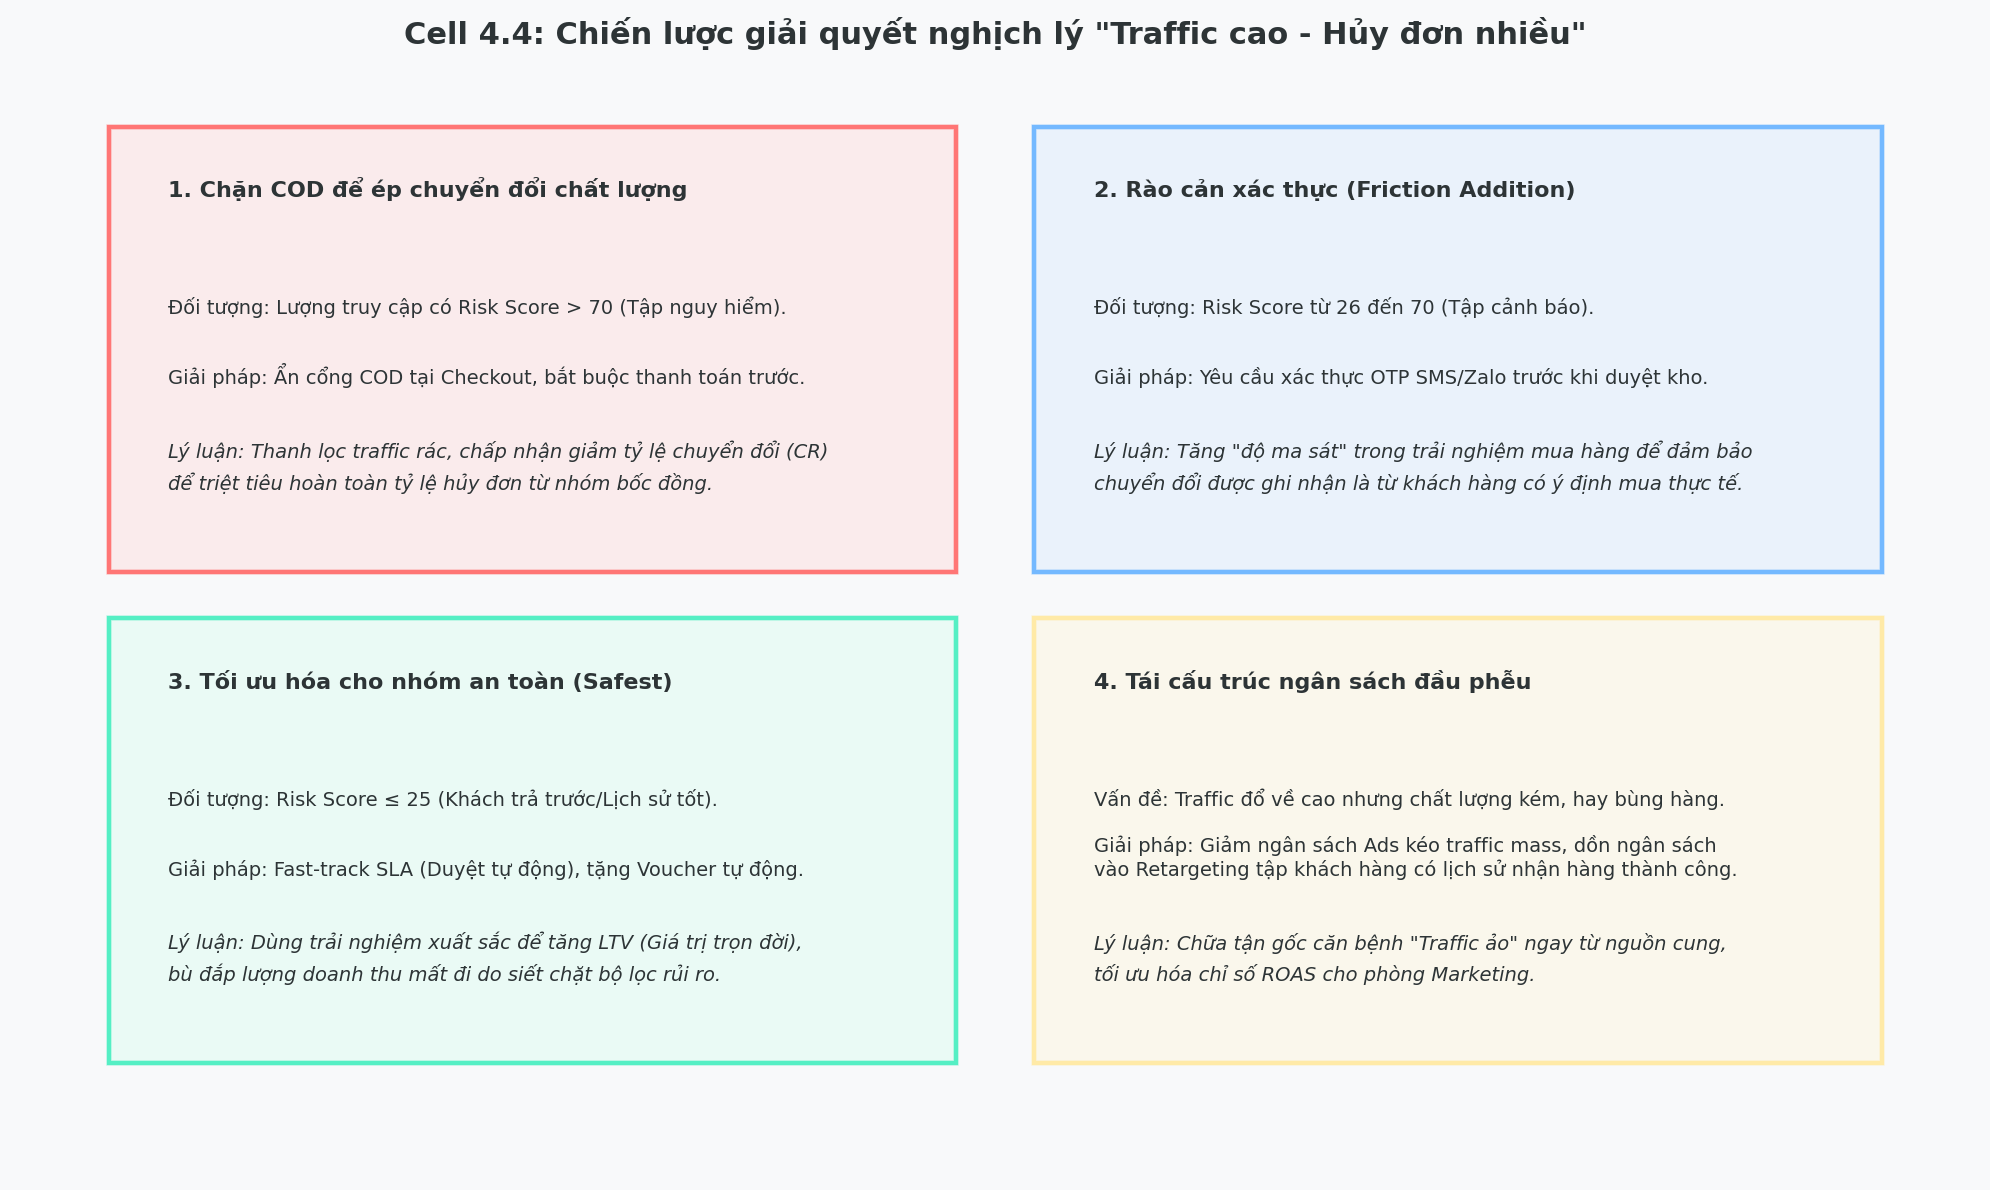

In [14]:
# ==============================================================================
# CELL 4.4: PRESCRIPTIVE - TỔNG KẾT CHIẾN LƯỢC KINH DOANH TOÀN DIỆN
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os

# --- 1. SETUP ---
plt.close('all')
FIG_DIR = os.path.join('..', 'output', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

# --- 2. TRỰC QUAN HÓA (4 TRỤ CỘT CHIẾN LƯỢC) ---
fig, ax = plt.subplots(figsize=(20, 12), facecolor='#f8f9fa')
ax.axis('off')

# Tiêu đề chính
plt.text(0.5, 0.98, 'Cell 4.4: Chiến lược giải quyết nghịch lý "Traffic cao - Hủy đơn nhiều"', 
         ha='center', va='center', fontsize=22, fontweight='bold', color='#2d3436')

# Khai báo nội dung 4 khối (Đã fix logic T > 70 và bỏ in hoa)
strategies = [
    {
        'title': '1. Chặn COD để ép chuyển đổi chất lượng',
        'target': 'Đối tượng: Lượng truy cập có Risk Score > 70 (Tập nguy hiểm).',
        'action': 'Giải pháp: Ẩn cổng COD tại Checkout, bắt buộc thanh toán trước.',
        'logic': 'Lý luận: Thanh lọc traffic rác, chấp nhận giảm tỷ lệ chuyển đổi (CR)\nđể triệt tiêu hoàn toàn tỷ lệ hủy đơn từ nhóm bốc đồng.',
        'color': '#ff7675', 'bg': '#ffcccc', 'pos': (0.05, 0.52)
    },
    {
        'title': '2. Rào cản xác thực (Friction Addition)',
        'target': 'Đối tượng: Risk Score từ 26 đến 70 (Tập cảnh báo).',
        'action': 'Giải pháp: Yêu cầu xác thực OTP SMS/Zalo trước khi duyệt kho.',
        'logic': 'Lý luận: Tăng "độ ma sát" trong trải nghiệm mua hàng để đảm bảo\nchuyển đổi được ghi nhận là từ khách hàng có ý định mua thực tế.',
        'color': '#74b9ff', 'bg': '#cce5ff', 'pos': (0.52, 0.52)
    },
    {
        'title': '3. Tối ưu hóa cho nhóm an toàn (Safest)',
        'target': 'Đối tượng: Risk Score ≤ 25 (Khách trả trước/Lịch sử tốt).',
        'action': 'Giải pháp: Fast-track SLA (Duyệt tự động), tặng Voucher tự động.',
        'logic': 'Lý luận: Dùng trải nghiệm xuất sắc để tăng LTV (Giá trị trọn đời),\nbù đắp lượng doanh thu mất đi do siết chặt bộ lọc rủi ro.',
        'color': '#55efc4', 'bg': '#ccffeb', 'pos': (0.05, 0.1)
    },
    {
        'title': '4. Tái cấu trúc ngân sách đầu phễu',
        'target': 'Vấn đề: Traffic đổ về cao nhưng chất lượng kém, hay bùng hàng.',
        'action': 'Giải pháp: Giảm ngân sách Ads kéo traffic mass, dồn ngân sách\nvào Retargeting tập khách hàng có lịch sử nhận hàng thành công.',
        'logic': 'Lý luận: Chữa tận gốc căn bệnh "Traffic ảo" ngay từ nguồn cung,\ntối ưu hóa chỉ số ROAS cho phòng Marketing.',
        'color': '#ffeaa7', 'bg': '#fff4cc', 'pos': (0.52, 0.1)
    }
]

# Vẽ các khối chiến lược
for s in strategies:
    x, y = s['pos']
    # Vẽ hộp nền
    rect = patches.Rectangle((x, y), 0.43, 0.38, linewidth=4, edgecolor=s['color'], facecolor=s['bg'], alpha=0.3)
    ax.add_patch(rect)
    
    # Border nhấn
    rect_border = patches.Rectangle((x, y), 0.43, 0.38, linewidth=3, edgecolor=s['color'], facecolor='none')
    ax.add_patch(rect_border)

    # In chữ
    ax.text(x + 0.03, y + 0.32, s['title'], fontsize=16, fontweight='bold', color='#2d3436')
    ax.text(x + 0.03, y + 0.22, s['target'], fontsize=14, color='#2d3436')
    ax.text(x + 0.03, y + 0.16, s['action'], fontsize=14, color='#2d3436')
    ax.text(x + 0.03, y + 0.07, s['logic'], fontsize=14, color='#2d3436', style='italic', linespacing=1.6)

plt.tight_layout()
save_path = os.path.join(FIG_DIR, '4.4_Prescriptive_Business_Strategy_Fixed.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

1. Chặn COD để ép chuyển đổi chất lượng

    - đối tượng: nhóm khách hàng thuộc tập nguy hiểm có chỉ số rủi ro $T > 70$.

    - hành động: can thiệp trực tiếp vào giao diện người dùng (frontend) bằng cách ẩn hoàn toàn phương thức thanh toán khi nhận hàng (cod) tại bước checkout, bắt buộc khách hàng phải thanh toán trước qua ví điện tử hoặc thẻ ngân hàng.

    - ý nghĩa quản trị: doanh nghiệp chủ động thanh lọc "traffic rác", chấp nhận hy sinh một phần nhỏ tỷ lệ chuyển đổi (cr) ảo để đánh đổi lấy sự an toàn tuyệt đối cho dòng tiền, triệt tiêu chi phí khứ hồi từ nhóm khách hàng bốc đồng.

2. Tạo rào cản xác thực (Friction addition)

    - đối tượng: nhóm khách hàng thuộc tập cảnh báo có chỉ số rủi ro dao động từ 26 đến 70 (những đơn cod có giá trị thấp hoặc lạm dụng mã khuyến mãi).

    - hành động: thiết lập rào cản kỹ thuật bằng cách yêu cầu xác thực hệ thống (nhập mã otp qua sms/zalo) trước khi đẩy lệnh xuất kho.

    - ý nghĩa quản trị: việc tăng cường "độ ma sát" trong hành trình trải nghiệm mua sắm đóng vai trò như một màng lọc tâm lý, đảm bảo mọi chuyển đổi được ghi nhận đều xuất phát từ ý định mua hàng thực tế, loại bỏ triệt để tình trạng dùng công cụ (tool) đặt hàng ảo phá hoại hệ thống.

3. Tối ưu hóa trải nghiệm cho nhóm an toàn (Safest)

    - đối tượng: nhóm khách hàng mang lại giá trị thực với chỉ số rủi ro $T \le 25$ (chủ yếu là tập khách hàng thanh toán trước).

    - hành động: đưa vào luồng ưu tiên (fast-track sla) với cơ chế duyệt đơn tự động, ưu tiên xuất kho hỏa tốc và tự động tặng voucher tri ân cho các lần mua sau.

    - ý nghĩa quản trị: sử dụng chất lượng dịch vụ xuất sắc để tối đa hóa giá trị vòng đời khách hàng (ltv - lifetime value), dùng chính nguồn doanh thu bền vững từ tập khách hàng trung thành này để bù đắp lại phần doanh thu đã mất đi do việc siết chặt bộ lọc ở trên.

4. Tái cấu trúc ngân sách đầu phễu (Marketing optimization)

    - vấn đề: gốc rễ của nghịch lý nằm ở việc thu hút quá nhiều traffic nhưng sai tệp khách hàng mục tiêu.

    - hành động: phòng marketing cần điều chỉnh lại tệp quảng cáo, cắt giảm ngân sách từ các chiến dịch kéo traffic đại trà (mass targeting) chuyên dùng mã giảm giá để câu kéo. thay vào đó, tái phân bổ ngân sách cho các chiến dịch bám đuổi (retargeting) tập trung vào những khách hàng đã có lịch sử nhận hàng thành công.

    - ý nghĩa quản trị: chữa bệnh từ gốc rễ nguồn cung, giúp tối ưu hóa chỉ số roas (return on ad spend) và tạo ra sự đồng bộ giữa nỗ lực của bộ phận marketing và năng lực xử lý của bộ phận vận hành logistics.